In [ ]:
import pandas as pd
import numpy as np

tropomi = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_world/data/Run_3/updated_tropomi_emissions_full_variables.csv')
# hourly_tropomi = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_world/data/Run_3/updated_tropomi_emissions_hourly_full_variables.csv)
power_plants = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_world/data/power_plant_location/power_plants_with_combined_nearby_stats.csv')

In [2]:
tropomi

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km,wind_speed,no2_std_radius,no2_mean_radius,no2_frac_valid_radius
0,CoCO2_10497,64.730500,177.499500,2018-05-01T01:04:27.498000Z,5.830154,-3.387597,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,251.258689,...,0.0,0.0,0.0,0.0,0.0,0.0,6.742886,6.187599e-07,0.000003,0.948240
1,CoCO2_10145,66.401272,-179.134065,2018-05-01T01:04:53.418000Z,1.041227,-2.374036,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,242.675081,...,0.0,0.0,0.0,0.0,0.0,0.0,2.592335,6.373462e-07,0.000002,120.789434
2,CoCO2_10374,48.800410,132.909425,2018-05-01T02:43:15.877000Z,2.070041,-0.707398,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,3818.563776,...,1.0,73623.0,1.0,73623.0,4.0,850317.0,2.187575,6.469726e-06,0.000010,0.682338
3,CoCO2_07837,37.841115,140.946169,2018-05-01T02:39:48.522000Z,-2.893424,-1.283788,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,JPN,2121.208200,...,5.0,1536953.0,20.0,3412263.0,46.0,6361621.0,3.165440,4.081525e-06,0.000040,0.803517
4,CoCO2_07804,37.665675,141.014758,2018-05-01T02:39:45.282000Z,-3.242737,-0.939860,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,JPN,2121.208200,...,3.0,396526.0,18.0,3201307.0,49.0,6624657.0,3.376193,4.121700e-06,0.000038,0.789580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875575,CoCO2_13815,21.106000,-157.064700,2018-12-31T23:17:51.325000Z,-6.607008,-0.878363,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,475.187336,...,0.0,0.0,2.0,463811.0,2.0,463811.0,6.665139,1.988021e-06,0.000011,0.908144
875576,CoCO2_13814,20.790000,-156.934200,2018-12-31T23:17:45.925000Z,-4.027523,-3.016156,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,440.473555,...,0.0,0.0,0.0,0.0,2.0,463811.0,5.031713,2.612139e-06,0.000010,0.904516
875577,CoCO2_11676,21.478500,-158.058100,2018-12-31T23:18:03.205000Z,-6.011533,-0.585096,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,401.150322,...,2.0,463811.0,2.0,463811.0,2.0,463811.0,6.039939,2.369298e-06,0.000014,0.904171
875578,CoCO2_14352,21.311667,-158.113889,2018-12-31T23:18:01.045000Z,-9.188789,-0.178532,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,345.599202,...,2.0,463811.0,2.0,463811.0,2.0,463811.0,9.190524,2.742129e-06,0.000014,0.887136


In [3]:
cols_to_add = [
    'nearby_plants_count_20km', 'total_emission_20km', 'percentage_emission_20km',
    'nearby_plants_count_50km', 'total_emission_50km', 'percentage_emission_50km',
    'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km',
    'nearby_cities_count_20km', 'nearby_cities_pop_20km',
    'nearby_cities_count_50km', 'nearby_cities_pop_50km',
    'nearby_cities_count_100km', 'nearby_cities_pop_100km',
    'nearby_cities_count_200km', 'nearby_cities_pop_200km'
]

# pick only ID + the columns you want
pp_sub = power_plants[['ID'] + cols_to_add]

# merge onto tropomi by matching tropomi.location == power_plant.ID
tropomi_combined = tropomi.merge(
    pp_sub,
    how='left',
    left_on='location',
    right_on='ID'
).drop(columns='ID')

tropomi_combined_dropna = tropomi_combined.dropna()

In [4]:
tropomi_combined_dropna

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,total_emission_100km_y,percentage_emission_100km_y,nearby_cities_count_20km_y,nearby_cities_pop_20km_y,nearby_cities_count_50km_y,nearby_cities_pop_50km_y,nearby_cities_count_100km_y,nearby_cities_pop_100km_y,nearby_cities_count_200km_y,nearby_cities_pop_200km_y
0,CoCO2_10497,64.730500,177.499500,2018-05-01T01:04:27.498000Z,5.830154,-3.387597,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,251.258689,...,465.383761,53.989570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CoCO2_10145,66.401272,-179.134065,2018-05-01T01:04:53.418000Z,1.041227,-2.374036,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,242.675081,...,413.530990,58.683651,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,CoCO2_10374,48.800410,132.909425,2018-05-01T02:43:15.877000Z,2.070041,-0.707398,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,3818.563776,...,3818.563776,100.000000,1.0,73623.0,1.0,73623.0,1.0,73623.0,4.0,850317.0
3,CoCO2_07837,37.841115,140.946169,2018-05-01T02:39:48.522000Z,-2.893424,-1.283788,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,JPN,2121.208200,...,10909.628184,19.443451,0.0,0.0,5.0,1536953.0,20.0,3412263.0,46.0,6361621.0
4,CoCO2_07804,37.665675,141.014758,2018-05-01T02:39:45.282000Z,-3.242737,-0.939860,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,JPN,2121.208200,...,13065.529767,16.235149,1.0,52619.0,3.0,396526.0,18.0,3201307.0,49.0,6624657.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875575,CoCO2_13815,21.106000,-157.064700,2018-12-31T23:17:51.325000Z,-6.607008,-0.878363,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,475.187336,...,6632.640842,7.164376,0.0,0.0,0.0,0.0,2.0,463811.0,2.0,463811.0
875576,CoCO2_13814,20.790000,-156.934200,2018-12-31T23:17:45.925000Z,-4.027523,-3.016156,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,440.473555,...,5272.776921,8.353730,0.0,0.0,0.0,0.0,0.0,0.0,2.0,463811.0
875577,CoCO2_11676,21.478500,-158.058100,2018-12-31T23:18:03.205000Z,-6.011533,-0.585096,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,401.150322,...,12232.336025,3.279425,0.0,0.0,2.0,463811.0,2.0,463811.0,2.0,463811.0
875578,CoCO2_14352,21.311667,-158.113889,2018-12-31T23:18:01.045000Z,-9.188789,-0.178532,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,345.599202,...,12232.336025,2.825292,0.0,0.0,2.0,463811.0,2.0,463811.0,2.0,463811.0


In [10]:
tropomi_combined_dropna.to_csv(
    '/net/fs06/d3/rzhuang/TROPOMI_world/data/Run_1/processed_valid_tropomi_emissions_with_qa_with_all_vars.csv',
    index=False
)

In [46]:

import pandas as pd, numpy as np

f = '/net/fs06/d3/rzhuang/TROPOMI_world/data/Run_1/processed_valid_tropomi_emissions_with_qa_with_all_vars.csv'
df = pd.read_csv(f)

# df['no2_std_50km'] = np.sqrt(df['no2_var_50km'])
df['wind_speed'] = np.sqrt(df['wind_u']**2 + df['wind_v']**2)
# df.drop(columns='no2_var_50km', inplace=True)

df.to_csv(f, index=False)          # overwrite; change path if you prefer a new file

In [47]:
df

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km,wind_speed
0,CoCO2_10497,64.730500,177.499500,2018-05-01T01:04:27.498000Z,5.830154,-3.387597,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,251.258689,...,53.989570,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.742886
1,CoCO2_10145,66.401272,-179.134065,2018-05-01T01:04:53.418000Z,1.041227,-2.374036,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,242.675081,...,58.683651,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.592335
2,CoCO2_10374,48.800410,132.909425,2018-05-01T02:43:15.877000Z,2.070041,-0.707398,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,3818.563776,...,100.000000,1.0,73623.0,1.0,73623.0,1.0,73623.0,4.0,850317.0,2.187575
3,CoCO2_07837,37.841115,140.946169,2018-05-01T02:39:48.522000Z,-2.893424,-1.283788,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,JPN,2121.208200,...,19.443451,0.0,0.0,5.0,1536953.0,20.0,3412263.0,46.0,6361621.0,3.165440
4,CoCO2_07804,37.665675,141.014758,2018-05-01T02:39:45.282000Z,-3.242737,-0.939860,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,JPN,2121.208200,...,16.235149,1.0,52619.0,3.0,396526.0,18.0,3201307.0,49.0,6624657.0,3.376193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875575,CoCO2_13815,21.106000,-157.064700,2018-12-31T23:17:51.325000Z,-6.607008,-0.878363,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,475.187336,...,7.164376,0.0,0.0,0.0,0.0,2.0,463811.0,2.0,463811.0,6.665139
875576,CoCO2_13814,20.790000,-156.934200,2018-12-31T23:17:45.925000Z,-4.027523,-3.016156,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,440.473555,...,8.353730,0.0,0.0,0.0,0.0,0.0,0.0,2.0,463811.0,5.031713
875577,CoCO2_11676,21.478500,-158.058100,2018-12-31T23:18:03.205000Z,-6.011533,-0.585096,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,401.150322,...,3.279425,0.0,0.0,2.0,463811.0,2.0,463811.0,2.0,463811.0,6.039939
875578,CoCO2_14352,21.311667,-158.113889,2018-12-31T23:18:01.045000Z,-9.188789,-0.178532,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,345.599202,...,2.825292,0.0,0.0,2.0,463811.0,2.0,463811.0,2.0,463811.0,9.190524


In [2]:
import pandas as pd
import numpy as np

tropomi_combined_dropna = pd.read_csv(
    '/net/fs06/d3/rzhuang/TROPOMI_world/data/Run_3/updated_tropomi_emissions_full_variables.csv',
)


In [3]:
tropomi_combined_dropna

,location,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,country,annual_nox_emission,...,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km,wind_speed,no2_std_radius,no2_mean_radius,no2_frac_valid_radius
0,CoCO2_10497,64.730500,177.499500,2018-05-01T01:04:27.498000Z,5.830154,-3.387597,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,251.258689,...,0.0,0.0,0.0,0.0,0.0,0.0,6.742886,6.187599e-07,0.000003,0.948240
1,CoCO2_10145,66.401272,-179.134065,2018-05-01T01:04:53.418000Z,1.041227,-2.374036,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,242.675081,...,0.0,0.0,0.0,0.0,0.0,0.0,2.592335,6.373462e-07,0.000002,120.789434
2,CoCO2_10374,48.800410,132.909425,2018-05-01T02:43:15.877000Z,2.070041,-0.707398,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,RUS,3818.563776,...,1.0,73623.0,1.0,73623.0,4.0,850317.0,2.187575,6.469726e-06,0.000010,0.682338
3,CoCO2_07837,37.841115,140.946169,2018-05-01T02:39:48.522000Z,-2.893424,-1.283788,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,JPN,2121.208200,...,5.0,1536953.0,20.0,3412263.0,46.0,6361621.0,3.165440,4.081525e-06,0.000040,0.803517
4,CoCO2_07804,37.665675,141.014758,2018-05-01T02:39:45.282000Z,-3.242737,-0.939860,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,JPN,2121.208200,...,3.0,396526.0,18.0,3201307.0,49.0,6624657.0,3.376193,4.121700e-06,0.000038,0.789580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875575,CoCO2_13815,21.106000,-157.064700,2018-12-31T23:17:51.325000Z,-6.607008,-0.878363,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,475.187336,...,0.0,0.0,2.0,463811.0,2.0,463811.0,6.665139,1.988021e-06,0.000011,0.908144
875576,CoCO2_13814,20.790000,-156.934200,2018-12-31T23:17:45.925000Z,-4.027523,-3.016156,True,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,440.473555,...,0.0,0.0,0.0,0.0,2.0,463811.0,5.031713,2.612139e-06,0.000010,0.904516
875577,CoCO2_11676,21.478500,-158.058100,2018-12-31T23:18:03.205000Z,-6.011533,-0.585096,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,401.150322,...,2.0,463811.0,2.0,463811.0,2.0,463811.0,6.039939,2.369298e-06,0.000014,0.904171
875578,CoCO2_14352,21.311667,-158.113889,2018-12-31T23:18:01.045000Z,-9.188789,-0.178532,False,../data/TROPOMI_2018_data/S5P_RPRO_L2__NO2____...,USA,345.599202,...,2.0,463811.0,2.0,463811.0,2.0,463811.0,9.190524,2.742129e-06,0.000014,0.887136


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as pnotlt

# tropomi_combined_dropna['wind_speed'] = np.sqrt(tropomi_combined_dropna['wind_u']**2 + tropomi_combined_dropna['wind_v']**2)

# print(X)
X = tropomi_combined_dropna.iloc[:,9:]
# X = df.loc['surface_albedo']

y = tropomi_combined_dropna["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.7880490646200233
Precision: 0.28565748141079167
Recall: 0.9237495178089238
F1 Score: 0.43637247160298853
Confusion Matrix:
 [[123632  35930]
 [  1186  14368]]
AUC: 0.9201522752339338
Classification Report:
               precision    recall  f1-score   support

       False       0.99      0.77      0.87    159562
        True       0.29      0.92      0.44     15554

    accuracy                           0.79    175116
   macro avg       0.64      0.85      0.65    175116
weighted avg       0.93      0.79      0.83    175116

Kappa: 0.3478919745070467


In [21]:
# load the full power_plants DF
power_plants = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_world/data/power_plant_location/power_plants_with_combined_nearby_stats.csv')

# filter: no other plants within 20 km, but at least one city within 20 km
mask = (
    (power_plants['nearby_plants_count_20km'] == 0) &
    (power_plants['nearby_cities_count_20km'] == 0)
)

# apply filter and take the first 100 (or, if you have a ranking metric, sort before .head)
top100 = power_plants.loc[mask].head(100)

top50 = power_plants.loc[mask].head(50)

top20 = power_plants.loc[mask].head(20)

In [22]:
filtered_100 = tropomi_combined_dropna[tropomi_combined_dropna['location'].isin(top100['ID'])]
filtered_50 = tropomi_combined_dropna[tropomi_combined_dropna['location'].isin(top50['ID'])]
filtered_20 = tropomi_combined_dropna[tropomi_combined_dropna['location'].isin(top20['ID'])]

In [161]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score

# Get all available features
all_features = tropomi_combined_dropna.columns[9:].tolist()

# Your current baseline features
base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km',  'tisr','t2m',
        'surface_pressure', 'cloud_fraction_crb', 'cloud_albedo_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_altitude', 'surface_altitude_precision', 'surface_albedo_nitrogendioxide_window', 'surface_albedo', 'solar_zenith_angle', 'nearby_cities_count_50km','nearby_cities_pop_200km']

# base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km',
#        'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision',
#        'surface_classification', 'surface_pressure', 'surface_albedo',
#        'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
#        'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
#        'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
#        'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
#        'tropospheric_NO2_column_number_density', 'sensor_altitude',
#        'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
#        'solar_zenith_angle', 'tisr', 'tcwv', 't2m',     'nearby_plants_count_50km', 'total_emission_50km', 'percentage_emission_20km',
#        'percentage_emission_50km', 'nearby_plants_count_100km',
#        'total_emission_100km', 'percentage_emission_100km',
#        'nearby_cities_count_50km', 'nearby_cities_pop_50km',
#        'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'nearby_cities_pop_200km']

print("Base features:", base_features)
# base results
X = tropomi_combined_dropna[base_features]
y = tropomi_combined_dropna['plume_label'].astype(bool)
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[base_features]
y_tr_bal = df_bal['y']
# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)
# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)
print("Base model performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

# Features to test (exclude those already in the baseline)
features_to_test = [f for f in all_features if f not in base_features]

results = []

# Test each additional feature
for feature in features_to_test:
    # Create feature set with the new feature added
    test_features = base_features + [feature]
    
    # Subset data
    X = tropomi_combined_dropna[test_features]
    y = tropomi_combined_dropna['plume_label'].astype(bool)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Simple oversample minority class
    df_tr = X_train.copy(); df_tr['y'] = y_train
    maj = df_tr['y'].value_counts().idxmax()
    minc = df_tr['y'].value_counts().idxmin()
    maj_df = df_tr[df_tr['y']==maj]
    min_df = df_tr[df_tr['y']==minc]
    min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
    df_bal = pd.concat([maj_df, min_up])
    X_tr_bal = df_bal[test_features]
    y_tr_bal = df_bal['y']
    
    # Scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_bal)
    X_te_s = scaler.transform(X_test)
    
    # Train & evaluate
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr_s, y_tr_bal)
    y_pred = model.predict(X_te_s)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1])
    
    # Store results
    results.append({
        'feature': feature,
        'accuracy': acc,
        'f1_score': f1,
        'kappa': kappa,
        'auc': auc
    })
    
    print(f"Tested: {feature}, Accuracy: {acc:.4f}, F1: {f1:.4f}, Kappa: {kappa:.4f}, AUC: {auc:.4f}")

# Convert to DataFrame and sort by accuracy
results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)

# Display top 10 features
print("\nTop 10 features by accuracy:")
print(results_df.head(10))

# Get the best feature
best_feature = results_df.iloc[0]['feature']
print(f"\nBest feature to add: {best_feature}")

# Build final model with best feature added
best_features = base_features + [best_feature]
print(f"\nFinal feature set: {best_features}")

# Train and evaluate the model with the best feature added
X = tropomi_combined_dropna[best_features]
y = tropomi_combined_dropna['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[best_features]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("\nFinal model performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

Base features: ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 'tisr', 't2m', 'surface_pressure', 'cloud_fraction_crb', 'cloud_albedo_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_altitude', 'surface_altitude_precision', 'surface_albedo_nitrogendioxide_window', 'surface_albedo', 'solar_zenith_angle', 'nearby_cities_count_50km', 'nearby_cities_pop_200km']
Base model performance:
Accuracy: 0.8598814500102789
Precision: 0.30342083382824564
Recall: 0.904487917146145
F1 Score: 0.45440597691948503
Confusion:
 [[140361  23458]
 [  1079  10218]]
AUC: 0.9469145970388736
Classification:
               precision    recall  f1-score   support

       False       0.99      0.86      0.92    163819
        True       0.30      0.90      0.45     11297

    accuracy                           0.86    175116
   macro avg       0.65      0.88      0.69    175116
weighted avg       0.95      0.86      0.89    175116

Kap

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# print(X)
X = filtered_100.iloc[:,9:]
# X = filtered_100[:,9:]

y = filtered_100["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.7954842931937173
Precision: 0.6918032786885245
Recall: 0.871900826446281
F1 Score: 0.7714808043875686
Confusion Matrix:
 [[1376  470]
 [ 155 1055]]
AUC: 0.8892288889087864
Classification Report:
               precision    recall  f1-score   support

       False       0.90      0.75      0.81      1846
        True       0.69      0.87      0.77      1210

    accuracy                           0.80      3056
   macro avg       0.80      0.81      0.79      3056
weighted avg       0.82      0.80      0.80      3056

Kappa: 0.5908013865620032


In [188]:
import pandas as pd

df1 = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_US/data/processed_valid_tropomi_emissions_with_qa_with_t2m.csv')
df2 = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_US/data/processed_valid_tropomi_hourly_emissions_with_qa.csv')

In [237]:
df3 = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_US/data/Run_1000/valid_tropomi_emissions_with_qa.csv')
df4 = pd.read_csv('/net/fs06/d3/rzhuang/TROPOMI_US/data/Run_1020/valid_tropomi_emissions_with_qa.csv')

In [248]:
(abs(df3['no2_std_50km'] - df4['no2_std_50km']))/df3['no2_std_50km']

0         0.754623
1         0.585534
2         0.375077
3         0.122548
4         0.238690
            ...   
639896    0.024001
639897    0.155177
639898    0.207309
639899    0.105029
639900    0.360750
Name: no2_std_50km, Length: 639901, dtype: float64

In [243]:
df3['no2_std_50km']

0         0.000003
1         0.000008
2         0.000006
3         0.000005
4         0.000004
            ...   
639896    0.000004
639897    0.000004
639898    0.000006
639899    0.000006
639900    0.000006
Name: no2_std_50km, Length: 639901, dtype: float64

In [244]:
df4['no2_std_50km']

0         0.000006
1         0.000003
2         0.000008
3         0.000005
4         0.000004
            ...   
639896    0.000004
639897    0.000004
639898    0.000004
639899    0.000006
639900    0.000004
Name: no2_std_50km, Length: 639901, dtype: float64

In [177]:
df1['plume_label'] 

0         False
1         False
2         False
3         False
4         False
          ...  
501748    False
501749    False
501750    False
501751    False
501752    False
Name: plume_label, Length: 501753, dtype: bool

In [215]:
df2['no2_std_50km']

0         0.000009
1         0.000007
2         0.000005
3         0.000003
4         0.000003
            ...   
501748    0.000003
501749    0.000003
501750    0.000004
501751    0.000005
501752    0.000008
Name: no2_std_50km, Length: 501753, dtype: float64

In [212]:
df1['no2_std_50km']

0         0.000022
1         0.000016
2         0.000009
3         0.000009
4         0.000008
            ...   
639403    0.000007
639404    0.000004
639405    0.000006
639406    0.000008
639407    0.000012
Name: no2_std_50km, Length: 639408, dtype: float64

In [192]:
df1.columns

Index(['location', 'facility_id', 'latitude', 'longitude', 'utc_time',
       'wind_u', 'wind_v', 'plume_label', 'file_path', 'State',
       'annual_nox_emission', 'no2_mean_50km', 'no2_var_50km',
       'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'nearby_plants_count_20km', 'total_emission_20km',
       'percentage_emission_20km', 'nearby_plants_count_50km',
       'total_emission_50km', 'percentage_emission_50km',
       'nearby_plants

In [178]:
df1.columns

Index(['location', 'facility_id', 'latitude', 'longitude', 'utc_time',
       'wind_u', 'wind_v', 'plume_label', 'file_path', 'State',
       'annual_nox_emission', 'no2_mean_50km', 'no2_frac_valid_50km',
       'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'nearby_plants_count_20km', 'total_emission_20km',
       'percentage_emission_20km', 'nearby_plants_count_50km',
       'total_emission_50km', 'percentage_emission_50km',
       'nearby_plants_count_100km', '

In [179]:
df2

,location,facility_id,latitude,longitude,utc_time,wind_u,wind_v,plume_label,file_path,State,...,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km,no2_std_50km,wind_speed,t2m,noxMass,tisr,tcwv
0,Monroe,1733,41.8917,-83.3461,2022-07-26T17:47:20.315000Z,-2.866145,-0.444594,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,MI,...,21.0,6322934.0,34.0,9517304.0,0.000009,2.900423,297.25537,1546.200,4369408.0,21.591183
1,Curtis H. Stanton Energy Center,564,28.4836,-81.1686,2022-07-26T17:43:49.480000Z,-2.104258,0.839091,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,FL,...,18.0,4588552.0,38.0,9888819.0,0.000007,2.265386,305.07178,1554.920,4676736.0,52.235714
2,Midland Cogeneration Venture,10745,43.5861,-84.2242,2022-07-26T17:47:50.554000Z,1.965593,1.022644,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,MI,...,3.0,475039.0,28.0,7445367.0,0.000005,2.215707,299.95850,1149.400,4317312.0,23.026730
3,J H Campbell,1710,42.9103,-86.2036,2022-07-26T17:47:53.914000Z,3.677128,0.940488,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,MI,...,6.0,1212616.0,20.0,4084959.0,0.000003,3.795496,296.04443,1054.000,4325248.0,24.948605
4,Cross,130,33.3692,-80.1119,2022-07-26T17:44:54.158000Z,1.369652,3.087514,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,SC,...,6.0,1126076.0,9.0,2378372.0,0.000003,3.377675,304.78662,893.700,4598144.0,45.466183
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61016,H F Lee Steam Electric Plant,2709,35.3775,-78.0875,2023-05-10T17:48:10.288000Z,-2.990151,-1.523342,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,NC,...,8.0,2425657.0,11.0,2900616.0,0.000003,3.355827,296.31592,179.600,4548224.0,13.855973
61017,Northport,2516,40.9231,-73.3417,2023-05-10T17:49:13.287000Z,2.474792,1.681904,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,NY,...,58.0,36136637.0,76.0,39061222.0,0.000062,2.992223,291.74756,43.197,4349568.0,10.629411
61018,Sanford,620,28.8419,-81.3256,2023-05-10T17:46:53.010000Z,-0.978602,-0.051669,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,FL,...,17.0,3966798.0,34.0,10462879.0,0.000006,0.979965,303.87450,314.696,4702080.0,38.639175
61019,E F Barrett,2511,40.6169,-73.6486,2023-05-10T17:49:09.927000Z,2.203936,1.913960,False,../data/TROPOMI_2019-2024/S5P_OFFL_L2__NO2____...,NY,...,62.0,36115485.0,83.0,44717288.0,0.000091,2.919003,290.52880,88.300,4370816.0,11.662614


In [180]:
df2.columns

Index(['location', 'facility_id', 'latitude', 'longitude', 'utc_time',
       'wind_u', 'wind_v', 'plume_label', 'file_path', 'State',
       'annual_nox_emission', 'no2_mean_50km', 'no2_frac_valid_50km',
       'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'nearby_plants_count_20km', 'total_emission_20km',
       'percentage_emission_20km', 'nearby_plants_count_50km',
       'total_emission_50km', 'percentage_emission_50km',
       'nearby_plants_count_100km', '

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    cohen_kappa_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1) Prepare data
X = filtered_100.iloc[:, 9:].values.astype(np.float32)
y = filtered_100["plume_label"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# 2) Tensors & DataLoaders
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_ds = TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_bal))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_ds  = TensorDataset(torch.from_numpy(X_te_s), torch.from_numpy(y_test))
test_dl  = DataLoader(test_ds, batch_size=32)

# 3) Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLP(X_tr_s.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
# 4) Train with early stopping
best_loss = np.inf
patience, counter = 5, 0
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_loss = total_loss / len(train_dl.dataset)

    # print training progress
    print(f"Epoch {epoch+1}/{num_epochs} – train loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss, counter = avg_loss, 0
        torch.save(model.state_dict(), 'best.pt')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best.pt'))

# 5) Evaluate
model.eval()
probs = []
with torch.no_grad():
    for xb, _ in test_dl:
        xb = xb.to(device)
        probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
probs = np.array(probs)
preds = (probs >= 0.5).astype(int)

print("Accuracy:          ", accuracy_score(y_test, preds))
print("Precision:         ", precision_score(y_test, preds))
print("Recall:            ", recall_score(y_test, preds))
print("F1 Score:          ", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
print("AUC:               ", roc_auc_score(y_test, probs))
print("Classification Rep:\n", classification_report(y_test, preds))
print("Cohen's Kappa:     ", cohen_kappa_score(y_test, preds))

Epoch 1/100 – train loss: 0.6692
Epoch 2/100 – train loss: 0.6200
Epoch 3/100 – train loss: 0.5980
Epoch 4/100 – train loss: 0.5830
Epoch 5/100 – train loss: 0.5699
Epoch 6/100 – train loss: 0.5608
Epoch 7/100 – train loss: 0.5531
Epoch 8/100 – train loss: 0.5472
Epoch 9/100 – train loss: 0.5370
Epoch 10/100 – train loss: 0.5312
Epoch 11/100 – train loss: 0.5286
Epoch 12/100 – train loss: 0.5248
Epoch 13/100 – train loss: 0.5147
Epoch 14/100 – train loss: 0.5113
Epoch 15/100 – train loss: 0.5071
Epoch 16/100 – train loss: 0.5024
Epoch 17/100 – train loss: 0.5007
Epoch 18/100 – train loss: 0.4955
Epoch 19/100 – train loss: 0.4931
Epoch 20/100 – train loss: 0.4874
Epoch 21/100 – train loss: 0.4824
Epoch 22/100 – train loss: 0.4823
Epoch 23/100 – train loss: 0.4814
Epoch 24/100 – train loss: 0.4758
Epoch 25/100 – train loss: 0.4725
Epoch 26/100 – train loss: 0.4670
Epoch 27/100 – train loss: 0.4609
Epoch 28/100 – train loss: 0.4596
Epoch 29/100 – train loss: 0.4623
Epoch 30/100 – train lo

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# If you only want to filter your feature matrix X:
X = filtered_50.iloc[:, 9:]\
       .loc[:, ~filtered_50.iloc[:, 9:].columns.str.match(r'.*_\d+$')]
# X = filtered_50.iloc[:,9:]
y = filtered_50["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.839208410636982
Precision: 0.76010101010101
Recall: 0.8958333333333334
F1 Score: 0.8224043715846995
Confusion Matrix:
 [[755 190]
 [ 70 602]]
AUC: 0.9238882590073066
Classification Report:
               precision    recall  f1-score   support

       False       0.92      0.80      0.85       945
        True       0.76      0.90      0.82       672

    accuracy                           0.84      1617
   macro avg       0.84      0.85      0.84      1617
weighted avg       0.85      0.84      0.84      1617

Kappa: 0.677304964539007


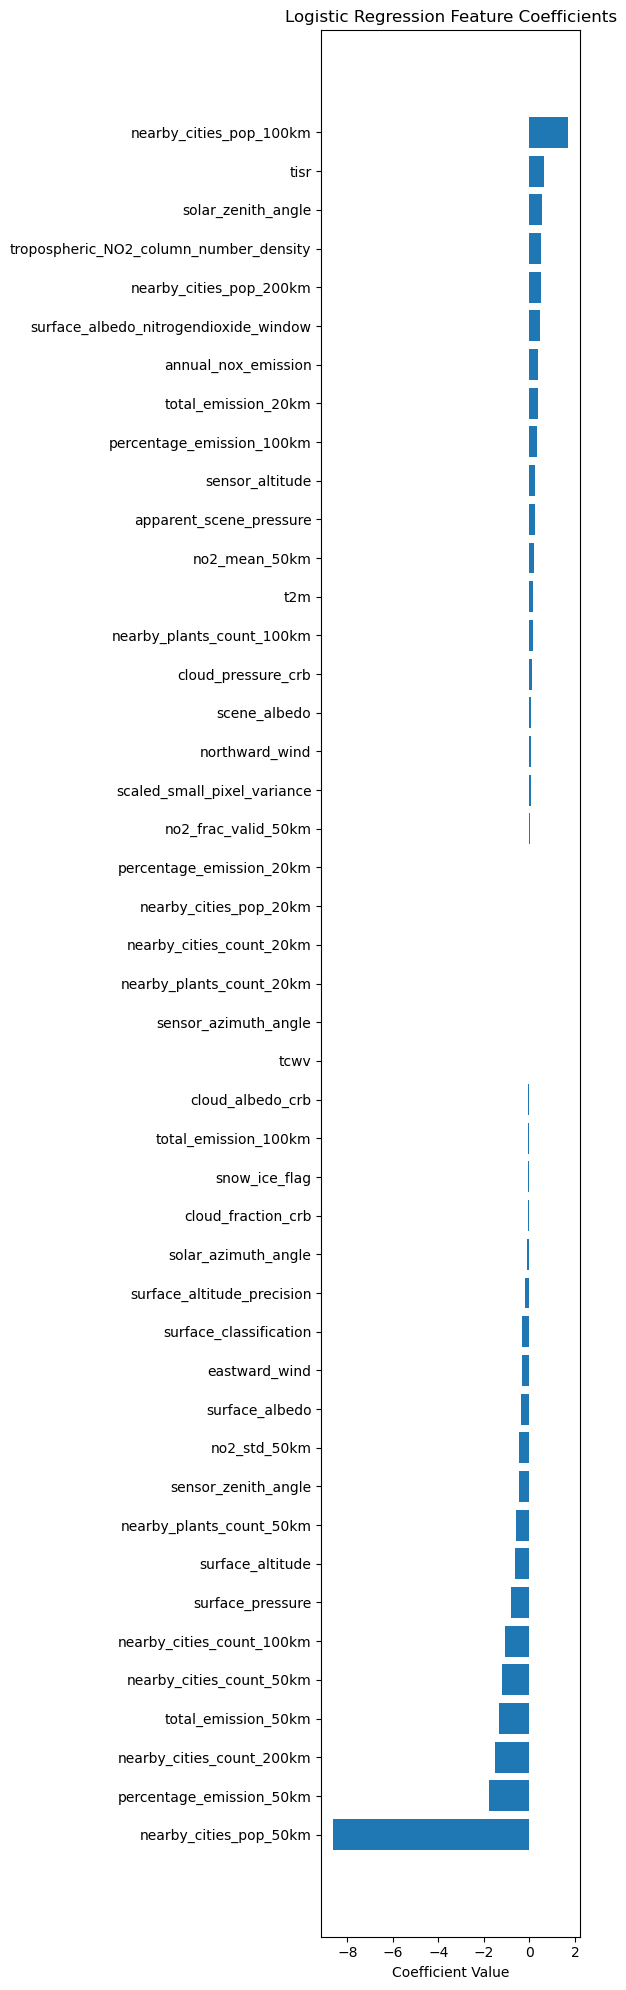

In [106]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [21]:
print(X.columns)

Index(['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km',
       'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'tisr', 'tcwv', 't2m', 'nearby_plants_count_20km',
       'total_emission_20km', 'percentage_emission_20km',
       'nearby_plants_count_50km', 'total_emission_50km',
       'percentage_emission_50km', 'nearby_plants_count_100km',
       'total_emission_100km', 'percentage_emission_100km',
       'nearby_cities_count_20km', 'n

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    cohen_kappa_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1) Prepare data
# X = filtered_50.iloc[:, 9:].values.astype(np.float32)
y = filtered_50["plume_label"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# 2) Tensors & DataLoaders
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_ds = TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_bal))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_ds  = TensorDataset(torch.from_numpy(X_te_s), torch.from_numpy(y_test))
test_dl  = DataLoader(test_ds, batch_size=32)

# 3) Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLP(X_tr_s.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 4) Train with early stopping
best_loss = np.inf
patience, counter = 5, 0
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    avg_loss = total_loss / len(train_dl.dataset)

    # print training progress
    print(f"Epoch {epoch+1}/{num_epochs} – train loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss, counter = avg_loss, 0
        torch.save(model.state_dict(), 'best.pt')
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best.pt'))

# 5) Evaluate
model.eval()
probs = []
with torch.no_grad():
    for xb, _ in test_dl:
        xb = xb.to(device)
        probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
probs = np.array(probs)
preds = (probs >= 0.5).astype(int)

print("Accuracy:          ", accuracy_score(y_test, preds))
print("Precision:         ", precision_score(y_test, preds))
print("Recall:            ", recall_score(y_test, preds))
print("F1 Score:          ", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
print("AUC:               ", roc_auc_score(y_test, probs))
print("Classification Rep:\n", classification_report(y_test, preds))
print("Cohen's Kappa:     ", cohen_kappa_score(y_test, preds))

RuntimeError: mat1 and mat2 must have the same dtype, but got Double and Float

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# print(X)
X = filtered_20.iloc[:,9:]
# X = filtered_100[:,9:]

y = filtered_20["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.8295625942684767
Precision: 0.726027397260274
Recall: 0.8653061224489796
F1 Score: 0.7895716945996276
Confusion Matrix:
 [[338  80]
 [ 33 212]]
AUC: 0.9203983985938873
Classification Report:
               precision    recall  f1-score   support

       False       0.91      0.81      0.86       418
        True       0.73      0.87      0.79       245

    accuracy                           0.83       663
   macro avg       0.82      0.84      0.82       663
weighted avg       0.84      0.83      0.83       663

Kappa: 0.648186672051317


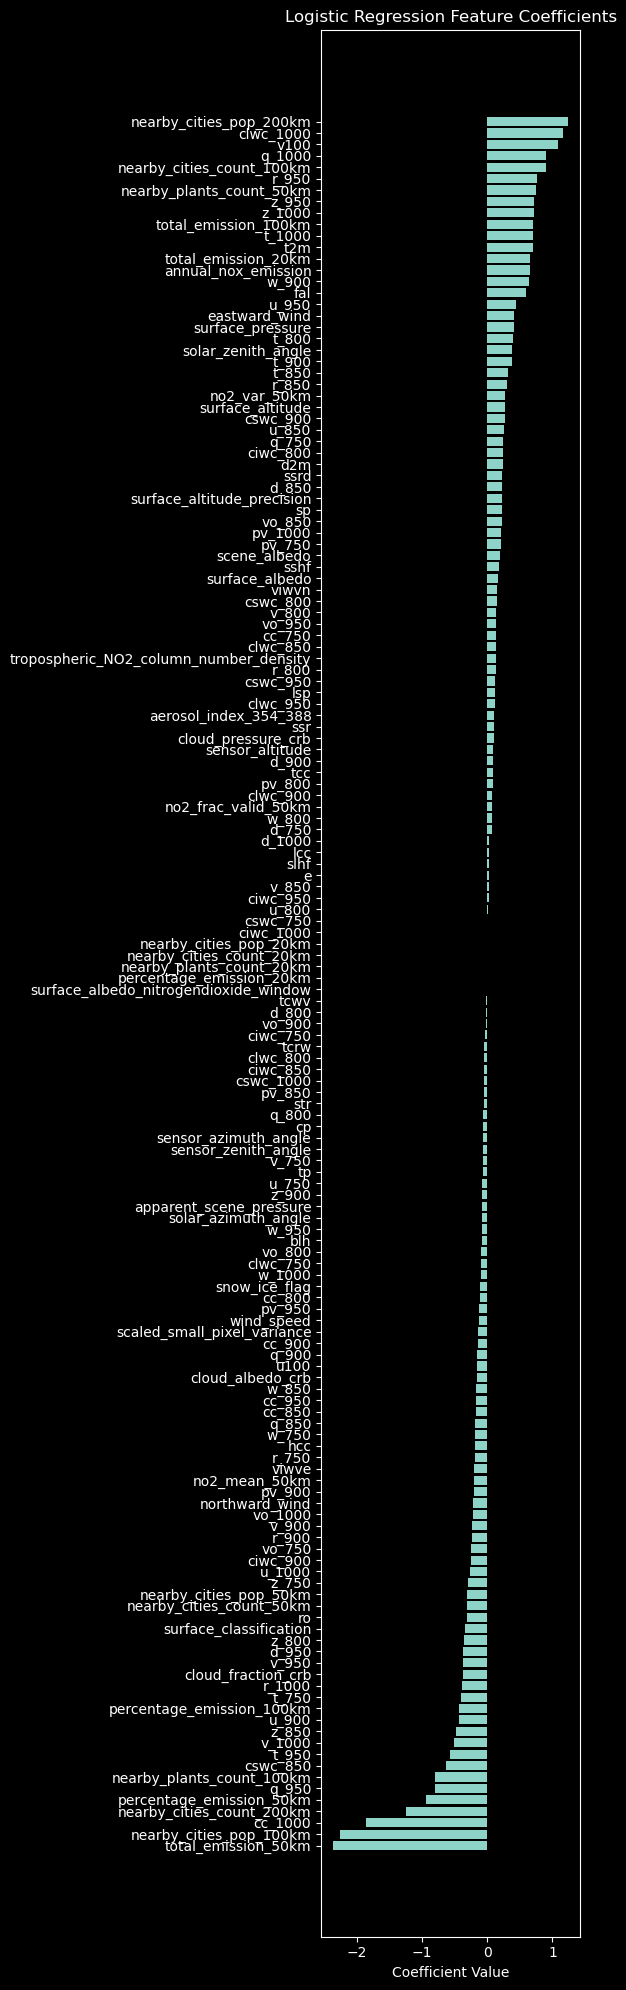

In [61]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    cohen_kappa_score
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 1) Prepare data
X = filtered_20.iloc[:, 9:].values.astype(np.float32)
y = filtered_20["plume_label"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# 2) Tensors & DataLoaders
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_ds = TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_bal))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_ds  = TensorDataset(torch.from_numpy(X_te_s), torch.from_numpy(y_test))
test_dl  = DataLoader(test_ds, batch_size=32)

# 3) Model
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            # nn.ReLU(),
            # nn.Dropout(0.3),
            # nn.Linear(256, 128),
            # nn.ReLU(),
            # nn.Dropout(0.3),
            # nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model = MLP(X_tr_s.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 4) Train with early stopping
best_loss = np.inf
patience, counter = 5, 0
num_epochs = 200

# after optimizer definition
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=True
)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device).float()
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_dl.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} – train loss: {avg_loss:.4f}")

    # step the scheduler on the training loss
    scheduler.step(avg_loss)

    # early stopping
    if avg_loss < best_loss:
        best_loss, counter = avg_loss, 0
        torch.save(model.state_dict(), 'best.pt')

model.load_state_dict(torch.load('best.pt'))

# 5) Evaluate
model.eval()
probs = []
with torch.no_grad():
    for xb, _ in test_dl:
        xb = xb.to(device)
        probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
probs = np.array(probs)
preds = (probs >= 0.5).astype(int)

print("Accuracy:          ", accuracy_score(y_test, preds))
print("Precision:         ", precision_score(y_test, preds))
print("Recall:            ", recall_score(y_test, preds))
print("F1 Score:          ", f1_score(y_test, preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
print("AUC:               ", roc_auc_score(y_test, probs))
print("Classification Rep:\n", classification_report(y_test, preds))
print("Cohen's Kappa:     ", cohen_kappa_score(y_test, preds))

/net/fs01/home/rzhuang/miniforge3/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/200 – train loss: 0.6136
Epoch 2/200 – train loss: 0.5445
Epoch 3/200 – train loss: 0.5142
Epoch 4/200 – train loss: 0.4975
Epoch 5/200 – train loss: 0.4803
Epoch 6/200 – train loss: 0.4648
Epoch 7/200 – train loss: 0.4457
Epoch 8/200 – train loss: 0.4373
Epoch 9/200 – train loss: 0.4397
Epoch 10/200 – train loss: 0.4189
Epoch 11/200 – train loss: 0.4093
Epoch 12/200 – train loss: 0.3964
Epoch 13/200 – train loss: 0.3972
Epoch 14/200 – train loss: 0.3880
Epoch 15/200 – train loss: 0.3708
Epoch 16/200 – train loss: 0.3644
Epoch 17/200 – train loss: 0.3685
Epoch 18/200 – train loss: 0.3616
Epoch 19/200 – train loss: 0.3535
Epoch 20/200 – train loss: 0.3386
Epoch 21/200 – train loss: 0.3280
Epoch 22/200 – train loss: 0.3214
Epoch 23/200 – train loss: 0.3306
Epoch 24/200 – train loss: 0.3176
Epoch 25/200 – train loss: 0.3254
Epoch 26/200 – train loss: 0.3134
Epoch 27/200 – train loss: 0.3144
Epoch 28/200 – train loss: 0.2936
Epoch 29/200 – train loss: 0.2978
Epoch 30/200 – train lo

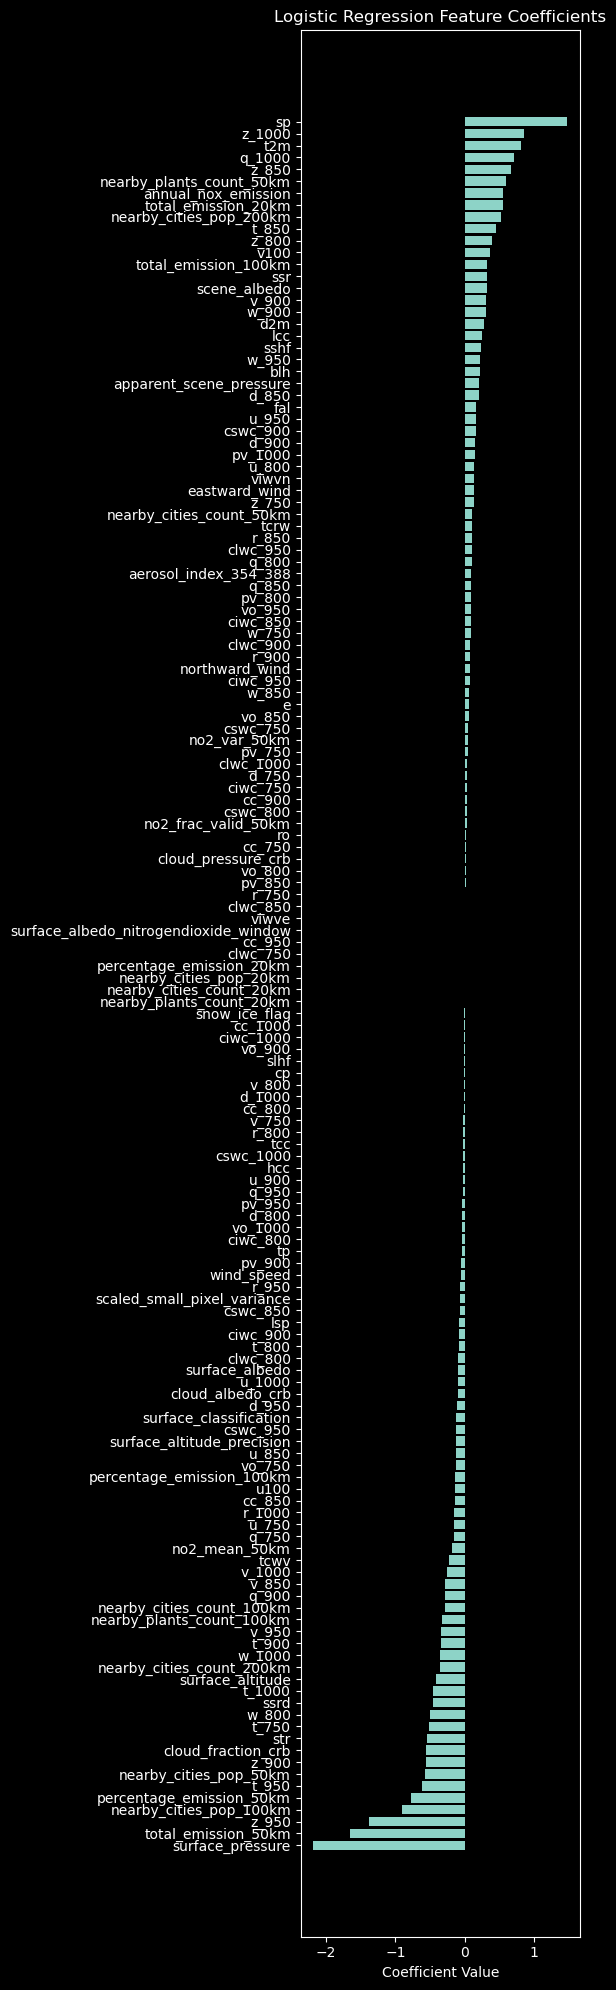

In [16]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import cohen_kappa_score

# filtered_50 is your DataFrame of 50 plants, with y = plume_label
y = filtered_50['plume_label'].astype(bool)
feature_cols = filtered_50.columns[9:]

results = []
for col in feature_cols:
    X = filtered_50[[col]]
    
    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # simple oversample minority class
    df_tr = X_train.copy()
    df_tr['y'] = y_train
    maj = df_tr['y'].value_counts().idxmax()
    minc = df_tr['y'].value_counts().idxmin()
    maj_df = df_tr[df_tr['y']==maj]
    min_df = df_tr[df_tr['y']==minc]
    min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
    df_bal = pd.concat([maj_df, min_up])
    
    X_tr_bal = df_bal[[col]]
    y_tr_bal = df_bal['y']
    
    # scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_bal)
    X_te_s = scaler.transform(X_test)
    
    # train & eval
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr_s, y_tr_bal)
    y_pred = model.predict(X_te_s)
    kappa = cohen_kappa_score(y_test, y_pred)
    
    results.append((col, kappa))

# build DataFrame & sort
df_kappa = pd.DataFrame(results, columns=['feature','kappa']) \
             .sort_values('kappa', ascending=False) \
             .reset_index(drop=True)

print(df_kappa)

                       feature     kappa
0       nearby_cities_pop_50km  0.219844
1    nearby_cities_count_100km  0.205296
2      nearby_cities_pop_100km  0.175376
3     nearby_cities_count_50km  0.168926
4     nearby_plants_count_50km  0.167269
..                         ...       ...
147                       v100 -0.023966
148                     v_1000 -0.025390
149                      w_800 -0.034004
150     surface_classification -0.042925
151                        fal -0.044317

[152 rows x 2 columns]


In [138]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score

# Get all available features
all_features = filtered_100.columns[9:].tolist()

# Your current baseline features
base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km',  'tisr','t2m',
        'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle', 'nearby_cities_count_50km', 'nearby_cities_pop_100km', 'nearby_plants_count_50km']

# base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km',
#        'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision',
#        'surface_classification', 'surface_pressure', 'surface_albedo',
#        'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
#        'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
#        'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
#        'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
#        'tropospheric_NO2_column_number_density', 'sensor_altitude',
#        'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
#        'solar_zenith_angle', 'tisr', 'tcwv', 't2m',     'nearby_plants_count_50km', 'total_emission_50km', 'percentage_emission_20km',
#        'percentage_emission_50km', 'nearby_plants_count_100km',
#        'total_emission_100km', 'percentage_emission_100km',
#        'nearby_cities_count_50km', 'nearby_cities_pop_50km',
#        'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'nearby_cities_pop_200km']

print("Base features:", base_features)
# base results
X = filtered_100[base_features]
y = filtered_100['plume_label'].astype(bool)
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[base_features]
y_tr_bal = df_bal['y']
# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)
# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)
print("Base model performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

# Features to test (exclude those already in the baseline)
features_to_test = [f for f in all_features if f not in base_features]

results = []

# Test each additional feature
for feature in features_to_test:
    # Create feature set with the new feature added
    test_features = base_features + [feature]
    
    # Subset data
    X = filtered_100[test_features]
    y = filtered_100['plume_label'].astype(bool)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Simple oversample minority class
    df_tr = X_train.copy(); df_tr['y'] = y_train
    maj = df_tr['y'].value_counts().idxmax()
    minc = df_tr['y'].value_counts().idxmin()
    maj_df = df_tr[df_tr['y']==maj]
    min_df = df_tr[df_tr['y']==minc]
    min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
    df_bal = pd.concat([maj_df, min_up])
    X_tr_bal = df_bal[test_features]
    y_tr_bal = df_bal['y']
    
    # Scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_bal)
    X_te_s = scaler.transform(X_test)
    
    # Train & evaluate
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr_s, y_tr_bal)
    y_pred = model.predict(X_te_s)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1])
    
    # Store results
    results.append({
        'feature': feature,
        'accuracy': acc,
        'f1_score': f1,
        'kappa': kappa,
        'auc': auc
    })
    
    print(f"Tested: {feature}, Accuracy: {acc:.4f}, F1: {f1:.4f}, Kappa: {kappa:.4f}, AUC: {auc:.4f}")

# Convert to DataFrame and sort by accuracy
results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)

# Display top 10 features
print("\nTop 10 features by accuracy:")
print(results_df.head(10))

# Get the best feature
best_feature = results_df.iloc[0]['feature']
print(f"\nBest feature to add: {best_feature}")

# Build final model with best feature added
best_features = base_features + [best_feature]
print(f"\nFinal feature set: {best_features}")

# Train and evaluate the model with the best feature added
X = filtered_100[best_features]
y = filtered_100['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[best_features]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("\nFinal model performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

Base features: ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 'tisr', 't2m', 'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle', 'nearby_cities_count_50km', 'nearby_cities_pop_100km', 'nearby_plants_count_50km']
Base model performance:
Accuracy: 0.8111910994764397
Precision: 0.6416861826697893
Recall: 0.874468085106383
F1 Score: 0.7402071139126519
Confusion:
 [[1657  459]
 [ 118  822]]
AUC: 0.8960825322768773
Classification:
               precision    recall  f1-score   support

       False       0.93      0.78      0.85      2116
        True       0.64      0.87      0.74       940

    accuracy                           0.81      3056
   macro avg       0.79      0.83      0.80      3056
weighted avg       0.84      0.81      0.82      3056

Kappa: 0.5973342443280532
Tested: surface_altitude, Accuracy: 0.8105, F1:

In [26]:
feature_cols = filtered_50.columns[9:]
feature_cols[:26]

Index(['annual_nox_emission', 'no2_mean_50km', 'no2_var_50km',
       'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle'],
      dtype='object')

In [77]:
feature_cols = filtered_50.columns[9:]

feature_names = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
        'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km', 'nearby_cities_pop_100km', 'apparent_scene_pressure',
        't2m']

# Subset X to those top 60
X = tropomi_combined_dropna[feature_names]
y = tropomi_combined_dropna['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[feature_names]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

Accuracy: 0.7271237351241463
Precision: 0.17950028392958547
Recall: 0.6812010631420157
F1 Score: 0.2841305748228491
Confusion:
 [[117848  43347]
 [  4438   9483]]
AUC: 0.7745751100727986
Classification:
               precision    recall  f1-score   support

       False       0.96      0.73      0.83    161195
        True       0.18      0.68      0.28     13921

    accuracy                           0.73    175116
   macro avg       0.57      0.71      0.56    175116
weighted avg       0.90      0.73      0.79    175116

Kappa: 0.1810831230949178


In [76]:
feature_cols = filtered_50.columns[9:]

feature_names = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
        'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km', 'nearby_cities_pop_100km', 'apparent_scene_pressure', 't2m']

# Subset X to those top 60
X = filtered_100[feature_names]
y = filtered_100['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[feature_names]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

Accuracy: 0.612565445026178
Precision: 0.47158403869407495
Recall: 0.7155963302752294
F1 Score: 0.5685131195335277
Confusion:
 [[1092  874]
 [ 310  780]]
AUC: 0.673149504885811
Classification:
               precision    recall  f1-score   support

       False       0.78      0.56      0.65      1966
        True       0.47      0.72      0.57      1090

    accuracy                           0.61      3056
   macro avg       0.63      0.64      0.61      3056
weighted avg       0.67      0.61      0.62      3056

Kappa: 0.24302376764246603


In [157]:
feature_cols = filtered_50.columns[9:]

base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km',  'tisr','t2m',
        'surface_pressure', 'cloud_fraction_crb', 'cloud_albedo_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_altitude', 'surface_altitude_precision', 'surface_albedo_nitrogendioxide_window', 'surface_albedo', 'solar_zenith_angle', 'nearby_cities_count_50km','nearby_cities_pop_200km', 'total_emission_20km']

# base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km',
#        'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision',
#        'surface_classification', 'surface_pressure', 'surface_albedo',
#        'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
#        'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
#        'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
#        'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
#        'tropospheric_NO2_column_number_density', 'sensor_altitude',
#        'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
#        'solar_zenith_angle', 'tisr', 'tcwv', 't2m',     'nearby_plants_count_50km', 'total_emission_50km', 'percentage_emission_20km',
#        'percentage_emission_50km', 'nearby_plants_count_100km',
#        'total_emission_100km', 'percentage_emission_100km',
#        'nearby_cities_count_50km', 'nearby_cities_pop_50km',
#        'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'nearby_cities_pop_200km']

# Subset X to those top 60
X = filtered_50[best_features]
y = filtered_50['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[best_features]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

# Features to test (exclude those already in the baseline)
features_to_test = [f for f in all_features if f not in base_features]

results = []

# Test each additional feature
for feature in features_to_test:
    # Create feature set with the new feature added
    test_features = base_features + [feature]
    
    # Subset data
    X = filtered_50[test_features]
    y = filtered_50['plume_label'].astype(bool)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Simple oversample minority class
    df_tr = X_train.copy(); df_tr['y'] = y_train
    maj = df_tr['y'].value_counts().idxmax()
    minc = df_tr['y'].value_counts().idxmin()
    maj_df = df_tr[df_tr['y']==maj]
    min_df = df_tr[df_tr['y']==minc]
    min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
    df_bal = pd.concat([maj_df, min_up])
    X_tr_bal = df_bal[test_features]
    y_tr_bal = df_bal['y']
    
    # Scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_bal)
    X_te_s = scaler.transform(X_test)
    
    # Train & evaluate
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr_s, y_tr_bal)
    y_pred = model.predict(X_te_s)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1])
    
    # Store results
    results.append({
        'feature': feature,
        'accuracy': acc,
        'f1_score': f1,
        'kappa': kappa,
        'auc': auc
    })
    
    print(f"Tested: {feature}, Accuracy: {acc:.4f}, F1: {f1:.4f}, Kappa: {kappa:.4f}, AUC: {auc:.4f}")

# Convert to DataFrame and sort by accuracy
results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)

# Display top 10 features
print("\nTop 10 features by accuracy:")
print(results_df.head(10))

# Get the best feature
best_feature = results_df.iloc[0]['feature']
print(f"\nBest feature to add: {best_feature}")

# Build final model with best feature added
best_features = base_features + [best_feature]
print(f"\nFinal feature set: {best_features}")

# Train and evaluate the model with the best feature added
X = filtered_50[best_features]
y = filtered_50['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[best_features]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("\nFinal model performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

Accuracy: 0.8645640074211502
Precision: 0.7384868421052632
Recall: 0.8821218074656189
F1 Score: 0.8039391226499553
Confusion:
 [[949 159]
 [ 60 449]]
AUC: 0.920320512365862
Classification:
               precision    recall  f1-score   support

       False       0.94      0.86      0.90      1108
        True       0.74      0.88      0.80       509

    accuracy                           0.86      1617
   macro avg       0.84      0.87      0.85      1617
weighted avg       0.88      0.86      0.87      1617

Kappa: 0.7017271077157621
Tested: surface_classification, Accuracy: 0.8615, F1: 0.8007, Kappa: 0.6960, AUC: 0.9210
Tested: cloud_pressure_crb, Accuracy: 0.8615, F1: 0.7996, Kappa: 0.6951, AUC: 0.9213
Tested: scene_albedo, Accuracy: 0.8621, F1: 0.8014, Kappa: 0.6972, AUC: 0.9201
Tested: apparent_scene_pressure, Accuracy: 0.8609, F1: 0.7989, Kappa: 0.6939, AUC: 0.9208
Tested: snow_ice_flag, Accuracy: 0.8615, F1: 0.8007, Kappa: 0.6960, AUC: 0.9205
Tested: aerosol_index_354_388, Acc

In [113]:
feature_cols = filtered_50.columns[9:]

# feature_names = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
#         'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km',  'nearby_cities_pop_100km', 'apparent_scene_pressure', 't2m']

# Subset X to those top 60
X = filtered_50[feature_cols]
y = filtered_50['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
# after concatenating maj/min
X_tr_bal = df_bal[feature_cols]   # not feature_names
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

Accuracy: 0.862708719851577
Precision: 0.7266982622432859
Recall: 0.9037328094302554
F1 Score: 0.8056042031523643
Confusion:
 [[935 173]
 [ 49 460]]
AUC: 0.9369809139460825
Classification:
               precision    recall  f1-score   support

       False       0.95      0.84      0.89      1108
        True       0.73      0.90      0.81       509

    accuracy                           0.86      1617
   macro avg       0.84      0.87      0.85      1617
weighted avg       0.88      0.86      0.87      1617

Kappa: 0.7014073963168139


In [74]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score

# Get all available features
all_features = filtered_100.columns[9:].tolist()

# Your current baseline features
base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_var_50km', 'surface_altitude', 'sensor_altitude', 'surface_classification', 'wind_speed', 'surface_albedo', 'scene_albedo', 'cloud_fraction_crb', 'fal', 'sp', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle', 'hcc', 'tcc', 'sshf', 'str', 'd2m', 'viwve', 'cc_850', 'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'r_1000', 'd_850', 'd_800', 'vo_950', 't_850']

print("Base features:", base_features)
# base results
X = filtered_50[base_features]
y = filtered_50['plume_label'].astype(bool)
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[base_features]
y_tr_bal = df_bal['y']
# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)
# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)
print("Base model performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

# Features to test (exclude those already in the baseline)
features_to_test = [f for f in all_features if f not in base_features]

results = []

# Test each additional feature
for feature in features_to_test:
    # Create feature set with the new feature added
    test_features = base_features + [feature]
    
    # Subset data
    X = filtered_50[test_features]
    y = filtered_50['plume_label'].astype(bool)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Simple oversample minority class
    df_tr = X_train.copy(); df_tr['y'] = y_train
    maj = df_tr['y'].value_counts().idxmax()
    minc = df_tr['y'].value_counts().idxmin()
    maj_df = df_tr[df_tr['y']==maj]
    min_df = df_tr[df_tr['y']==minc]
    min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
    df_bal = pd.concat([maj_df, min_up])
    X_tr_bal = df_bal[test_features]
    y_tr_bal = df_bal['y']
    
    # Scale
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr_bal)
    X_te_s = scaler.transform(X_test)
    
    # Train & evaluate
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr_s, y_tr_bal)
    y_pred = model.predict(X_te_s)
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1])
    
    # Store results
    results.append({
        'feature': feature,
        'accuracy': acc,
        'f1_score': f1,
        'kappa': kappa,
        'auc': auc
    })
    
    print(f"Tested: {feature}, Accuracy: {acc:.4f}, F1: {f1:.4f}, Kappa: {kappa:.4f}, AUC: {auc:.4f}")

# Convert to DataFrame and sort by accuracy
results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)

# Display top 10 features
print("\nTop 10 features by accuracy:")
print(results_df.head(10))

# Get the best feature
best_feature = results_df.iloc[0]['feature']
print(f"\nBest feature to add: {best_feature}")

# Build final model with best feature added
best_features = base_features + [best_feature]
print(f"\nFinal feature set: {best_features}")

# Train and evaluate the model with the best feature added
X = filtered_50[best_features]
y = filtered_50['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[best_features]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("\nFinal model performance:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))

Base features: ['annual_nox_emission', 'no2_mean_50km', 'no2_var_50km', 'surface_altitude', 'sensor_altitude', 'surface_classification', 'wind_speed', 'surface_albedo', 'scene_albedo', 'cloud_fraction_crb', 'fal', 'sp', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle', 'hcc', 'tcc', 'sshf', 'str', 'd2m', 'viwve', 'cc_850', 'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'r_1000', 'd_850', 'd_800', 'vo_950', 't_850']
Base model performance:
Accuracy: 0.7105751391465677
Precision: 0.6197183098591549
Recall: 0.7857142857142857
F1 Score: 0.6929133858267716
Confusion:
 [[621 324]
 [144 528]]
AUC: 0.7594356261022928
Classification:
               precision    recall  f1-score   support

       False       0.81      0.66      0.73       945
        True       0.62      0.79      0.69       672

    accuracy                           0.71      1617
   macro avg   

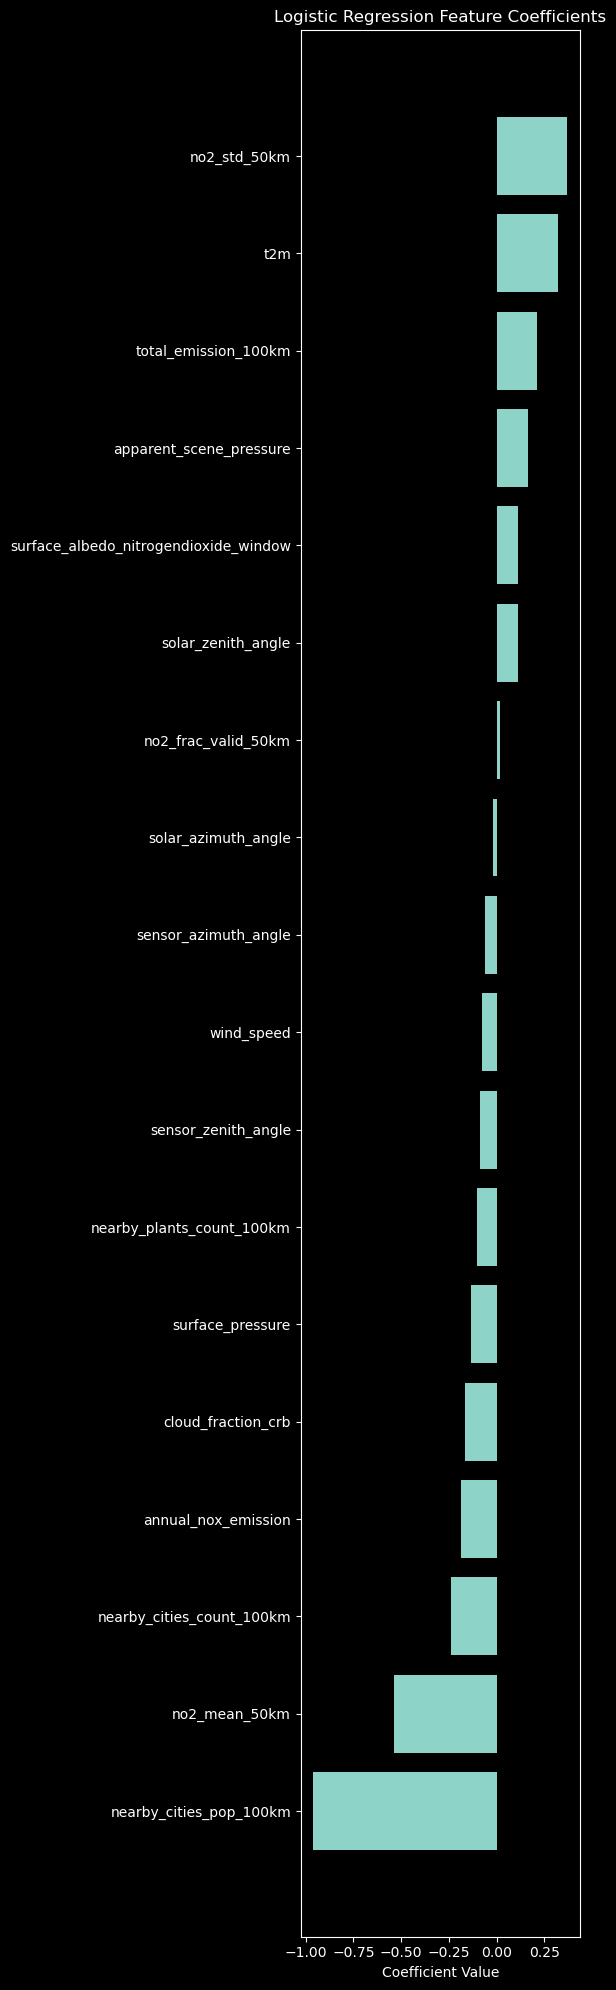

In [58]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
import shap

# 0. define your feature sets
all_features = filtered_100.columns[9:].tolist()

# base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km', 'no2_frac_valid_50km', 
#         'surface_pressure', 'cloud_fraction_crb', 'wind_speed', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'surface_albedo_nitrogendioxide_window', 'solar_zenith_angle','nearby_plants_count_100km', 'total_emission_100km', 'nearby_cities_pop_100km', 'apparent_scene_pressure', 't2m']


base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_std_50km',
       'no2_frac_valid_50km', 'surface_altitude', 'surface_altitude_precision',
       'surface_classification', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_pressure_crb',
       'cloud_fraction_crb', 'cloud_albedo_crb', 'scene_albedo',
       'apparent_scene_pressure', 'snow_ice_flag', 'aerosol_index_354_388',
       'eastward_wind', 'northward_wind', 'scaled_small_pixel_variance',
       'tropospheric_NO2_column_number_density', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'tisr', 'tcwv', 't2m',] #'nearby_plants_count_20km',
    #    'total_emission_20km', 'percentage_emission_20km',
    #    'nearby_plants_count_50km', 'total_emission_50km',
    #    'percentage_emission_50km', 'nearby_plants_count_100km',
    #    'total_emission_100km', 'percentage_emission_100km',
    #    'nearby_cities_count_20km', 'nearby_cities_pop_20km',
    #    'nearby_cities_count_50km', 'nearby_cities_pop_50km',
    #    'nearby_cities_count_100km', 'nearby_cities_pop_100km',
    #    'nearby_cities_count_200km', 'nearby_cities_pop_200km']

# (optional) extras you might test separately
features_to_test = [f for f in all_features if f not in base_features]

# 1. choose your model inputs
features = base_features  # or all_features, or base_features + features_to_test
X = tropomi_combined_dropna[features]
y = tropomi_combined_dropna['plume_label'].astype(bool)
plant_ids = tropomi_combined_dropna['location']

# 2. split
X_train, X_test, y_train, y_test, pid_train, pid_test = train_test_split(
    X, y, plant_ids, test_size=0.2, random_state=42
)

# 3. balance
ros = RandomOverSampler(random_state=42)
X_tr_bal, y_tr_bal = ros.fit_resample(X_train, y_train)

# 4. scale
scaler = StandardScaler().fit(X_tr_bal)
X_tr_s = scaler.transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# 5. train
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)

# 6. explain with SHAP
explainer = shap.Explainer(model, X_tr_s, feature_names=features)
shap_vals = explainer(X_te_s)  # (n_samples, n_features)

# 7. aggregate per‐plant
shap_abs = np.abs(shap_vals.values)
shap_df = pd.DataFrame(shap_abs, columns=features, index=X_test.index)
shap_df['plant_id'] = pid_test.values

mean_by_plant = shap_df.groupby('plant_id')[features].mean()
top_feature_per_plant = mean_by_plant.idxmax(axis=1)

# 8. result
print(top_feature_per_plant)

/net/fs01/home/rzhuang/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


plant_id
CoCO2_00006    nearby_cities_count_20km
CoCO2_00007      nearby_cities_pop_20km
CoCO2_00008      nearby_cities_pop_20km
CoCO2_00009      nearby_cities_pop_20km
CoCO2_00010      nearby_cities_pop_20km
                         ...           
CoCO2_16411    nearby_cities_count_20km
CoCO2_16417      nearby_cities_pop_20km
CoCO2_16420      nearby_cities_pop_20km
CoCO2_16422      nearby_cities_pop_20km
CoCO2_16424      nearby_cities_pop_20km
Length: 5998, dtype: object


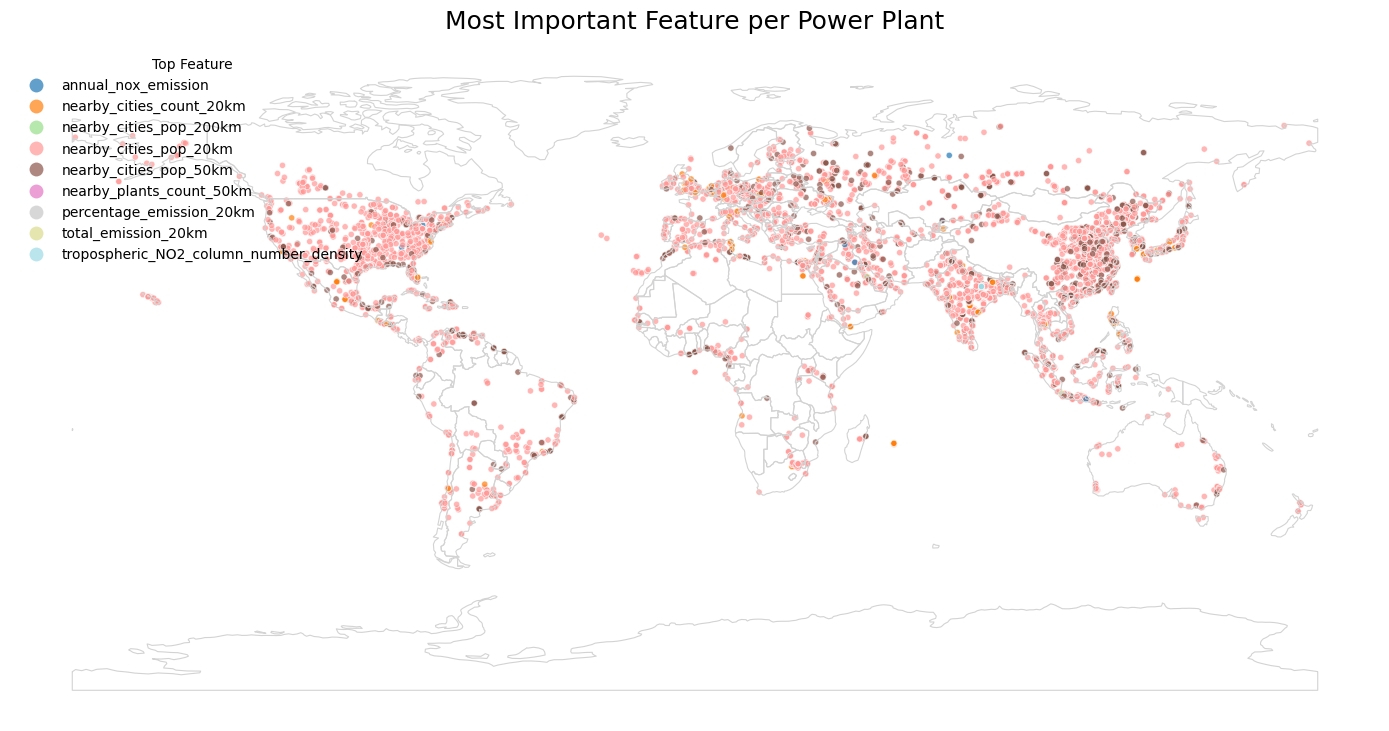

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
plt.rcdefaults()

# 1. Prepare coords + result
coords = (
    tropomi_combined_dropna[['location','latitude','longitude']]
    .drop_duplicates()
    .rename(columns={'location':'plant_id'})
)
result = (
    top_feature_per_plant
    .rename('top_feature')
    .reset_index()
    .rename(columns={'index':'plant_id'})
)
plot_df = pd.merge(result, coords, on='plant_id')

# 2. GeoDataFrame of plants
gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df.longitude, plot_df.latitude),
    crs="EPSG:4326"
)

# 3. Load world geometry from an online GeoJSON
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
)

# 4. Pretty‐plot
fig, ax = plt.subplots(figsize=(14,8))
ax.set_facecolor("#f5f5f5")

world.boundary.plot(ax=ax, color="lightgray", linewidth=0.8)

gdf.plot(
    ax=ax,
    column="top_feature",
    categorical=True,
    legend=True,
    legend_kwds={
        "title": "Top Feature",
        "loc": "upper left",
        "frameon": False,
        "fontsize": 10,
    },
    cmap="tab20",
    markersize=20,
    alpha=0.7,
    edgecolor="white",
    linewidth=0.5
)

ax.set_title("Most Important Feature per Power Plant", fontsize=18, pad=12)
ax.set_axis_off()
plt.savefig("top_feature_per_plant.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, cohen_kappa_score
from imblearn.over_sampling import RandomOverSampler

base_features = ['annual_nox_emission', 'no2_mean_50km', 'no2_var_50km',
       'no2_frac_valid_50km', 'surface_altitude', 'surface_pressure', 'surface_albedo',
       'surface_albedo_nitrogendioxide_window', 'cloud_fraction_crb', 
       'wind_speed', 'sensor_altitude',
       'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle',
       'solar_zenith_angle', 'total_emission_100km', 
       'percentage_emission_100km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km',
       'z_750', 'ssr', 'pv_950', 'd2m']
# base_features = ['annual_nox_emission', 'no2_mean_50km', 'surface_altitude', 'surface_altitude_precision', 'surface_classification', 'surface_albedo', 'cloud_fraction_crb', 'scene_albedo', 'apparent_scene_pressure', 'northward_wind', 'scaled_small_pixel_variance', 'sensor_altitude', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle', 'e', 'hcc', 'tcc', 'sshf', 'ssrd', 'str', 'd2m', 'tcwv', 'viwvn', 'viwve', 'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km']

results = []
for feat in base_features:
    feats = [f for f in base_features if f != feat]
    X = filtered_100[feats].values
    y = filtered_100['plume_label'].astype(bool).values

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    X_tr_bal, y_tr_bal = RandomOverSampler(random_state=42).fit_resample(X_tr, y_tr)

    scaler = StandardScaler().fit(X_tr_bal)
    X_tr_s = scaler.transform(X_tr_bal)
    X_te_s = scaler.transform(X_te)

    model = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_s, y_tr_bal)
    y_pred = model.predict(X_te_s)
    probs = model.predict_proba(X_te_s)[:,1]

    results.append({
        'dropped': feat,
        'auc': roc_auc_score(y_te, probs),
        'f1': f1_score(y_te, y_pred),
        'kappa': cohen_kappa_score(y_te, y_pred)
    })

df = pd.DataFrame(results).sort_values('auc', ascending=False)
print(df.head(10))

                      dropped       auc        f1     kappa
11       sensor_azimuth_angle  0.685924  0.560000  0.245101
22                        d2m  0.685149  0.563284  0.249866
3         no2_frac_valid_50km  0.684786  0.560641  0.246639
0         annual_nox_emission  0.684640  0.559878  0.245331
2                no2_var_50km  0.684632  0.560548  0.245896
6              surface_albedo  0.684608  0.557678  0.242147
21                     pv_950  0.684112  0.562047  0.249486
13        solar_azimuth_angle  0.684043  0.558565  0.243227
17  nearby_cities_count_100km  0.683832  0.561524  0.247716
8          cloud_fraction_crb  0.683591  0.556607  0.236931


In [103]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# print(X)
X = filtered_20.iloc[:,9:]
# X = filtered_100[:,9:]

y = filtered_20["plume_label"].astype(bool)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)
# model.fit(X_train_scaled, y_train_bal)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Kappa:", cohen_kappa_score(y_test, y_pred))


Accuracy: 0.8914027149321267
Precision: 0.78
Recall: 0.9198113207547169
F1 Score: 0.8441558441558441
Confusion Matrix:
 [[396  55]
 [ 17 195]]
AUC: 0.9620340543028072
Classification Report:
               precision    recall  f1-score   support

       False       0.96      0.88      0.92       451
        True       0.78      0.92      0.84       212

    accuracy                           0.89       663
   macro avg       0.87      0.90      0.88       663
weighted avg       0.90      0.89      0.89       663

Kappa: 0.7616846225275329


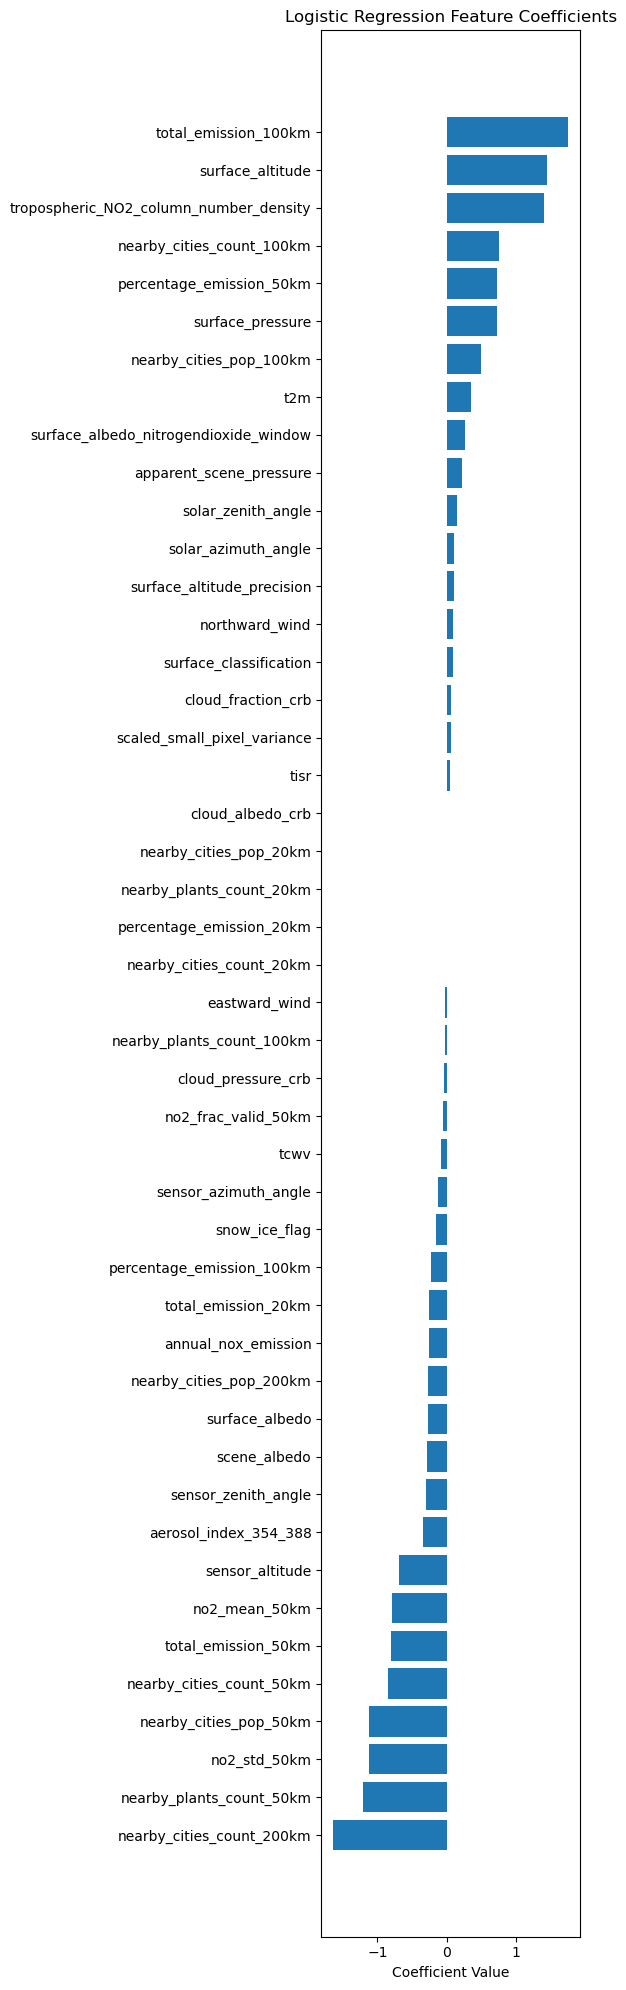

In [104]:
feature_names = X.columns
coefs = model.coef_[0]

# Sort coefficients for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, 20))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()

In [72]:
df_kappa[:60]

,feature,kappa
0,nearby_cities_pop_50km,0.219844
1,nearby_cities_count_100km,0.205296
2,nearby_cities_pop_100km,0.175376
3,nearby_cities_count_50km,0.168926
4,nearby_plants_count_50km,0.167269
5,total_emission_50km,0.154589
6,nearby_cities_count_200km,0.147380
7,pv_800,0.146835
8,sp,0.145796
9,surface_altitude,0.143417


In [21]:
features = df_kappa.head(60)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, cohen_kappa_score
)

# — assume you already have `df_kappa` from your single‐feature run —
# df_kappa = pd.DataFrame(...).sort_values('kappa', ascending=False)

top60 = df_kappa['feature'].iloc[:60].tolist()

# Subset X to those top 60
X = filtered_50[top60]
y = filtered_50['plume_label'].astype(bool)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# simple oversample minority class
df_tr = X_train.copy(); df_tr['y'] = y_train
maj = df_tr['y'].value_counts().idxmax()
minc = df_tr['y'].value_counts().idxmin()
maj_df = df_tr[df_tr['y']==maj]
min_df = df_tr[df_tr['y']==minc]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])
X_tr_bal = df_bal[top60]
y_tr_bal = df_bal['y']

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test)

# Train & evaluate
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_tr_s, y_tr_bal)
y_pred = model.predict(X_te_s)

print("Accuracy:",      accuracy_score(y_test, y_pred))
print("Precision:",     precision_score(y_test, y_pred))
print("Recall:",        recall_score(y_test, y_pred))
print("F1 Score:",      f1_score(y_test, y_pred))
print("Confusion:\n",   confusion_matrix(y_test, y_pred))
print("AUC:",           roc_auc_score(y_test, model.predict_proba(X_te_s)[:,1]))
print("Classification:\n", classification_report(y_test, y_pred))
print("Kappa:",         cohen_kappa_score(y_test, y_pred))

NameError: name 'df_kappa' is not defined

In [23]:
X

,annual_nox_emission,no2_mean_50km,no2_var_50km,no2_frac_valid_50km,surface_altitude,surface_altitude_precision,surface_classification,surface_pressure,surface_albedo,surface_albedo_nitrogendioxide_window,...,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km,wind_speed
33,7434.580038,0.000035,2.109658e-09,0.939021,956.342346,37.361210,110.0,91159.945312,0.154484,0.033501,...,100.000000,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5602076.0,1.512781
749,7920.364302,0.000034,1.228228e-10,0.867774,578.838562,12.452729,68.0,94178.671875,0.153721,0.075477,...,88.886898,0.0,0.0,2.0,439517.0,6.0,1036166.0,39.0,8624668.0,3.255436
757,6781.811933,0.000050,2.841916e-09,0.916543,296.780304,7.710897,46.0,96850.460938,0.203627,0.089281,...,23.394809,0.0,0.0,4.0,1789485.0,9.0,4518557.0,15.0,5710416.0,1.406202
758,6534.300549,0.000048,9.953696e-10,0.910098,327.661774,8.205189,20.0,96592.648438,0.237817,0.085836,...,44.594595,0.0,0.0,2.0,212411.0,8.0,1819120.0,25.0,4879640.0,0.509581
759,6534.300549,0.000060,2.382016e-10,0.932452,94.046570,9.086280,22.0,99249.070312,0.247649,0.091955,...,48.600884,0.0,0.0,1.0,1536218.0,7.0,4832711.0,25.0,8479916.0,3.976649
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874401,7029.277276,0.000033,1.487917e-09,0.929147,1943.386353,121.723015,68.0,80563.367188,0.188049,0.097160,...,100.000000,0.0,0.0,1.0,520944.0,6.0,1199358.0,14.0,4404825.0,3.571159
874608,10545.471125,0.000079,7.137360e-10,0.983057,1.101852,1.398971,126.0,101863.656250,0.046795,0.067584,...,25.588247,0.0,0.0,4.0,592890.0,26.0,11378224.0,61.0,46809796.0,4.704830
874609,10545.471125,0.000193,2.490364e-08,0.987064,386.992889,24.505028,148.0,97423.148438,0.425920,0.145885,...,19.195894,0.0,0.0,4.0,1011379.0,26.0,33481872.0,66.0,43907582.0,0.986326
874619,7765.458864,0.000040,8.172821e-10,1.018173,5.150510,3.858136,150.0,101358.906250,0.115345,0.114428,...,10.700392,0.0,0.0,1.0,4697000.0,2.0,7124924.0,6.0,7988490.0,7.377010


Exception ignored in: <function ResourceTracker.__del__ at 0x155301cb7060>
Traceback (most recent call last):
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x148913a3b060>
Traceback (most recent call last):
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No 

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, cohen_kappa_score
)

# 1) Load & filter power plants
# power_plants = pd.read_csv(
#     '/net/fs06/d3/rzhuang/TROPOMI_world/data/power_plant_location/power_plants_with_combined_nearby_stats.csv'
# )
# assume `filtered_50` is defined elsewhere, e.g. a subset of `power_plants`
# 2) Prepare X and y
# X = filtered_50.iloc[:, 9:]
X = filtered_50.iloc[:, 9:]\
       .loc[:, ~filtered_50.iloc[:, 9:].columns.str.match(r'.*_\d+$')]
y = filtered_50['plume_label'].astype(bool)

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Oversample minority class on the training set
df_tr = X_train.copy()
df_tr['y'] = y_train
counts = df_tr['y'].value_counts()
maj_df = df_tr[df_tr['y'] == counts.idxmax()]
min_df = df_tr[df_tr['y'] == counts.idxmin()]
min_up = min_df.sample(n=len(maj_df), replace=True, random_state=42)
df_bal = pd.concat([maj_df, min_up])

feature_cols = X_train.columns
X_tr_bal = df_bal[feature_cols]
y_tr_bal = df_bal['y']

# 5) Pre-filter highly correlated features (drop one of any pair with |corr| > 0.9)
corr_matrix = X_tr_bal.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
X_tr_bal = X_tr_bal.drop(columns=to_drop)
# apply same drop to X_test
X_test = X_test.drop(columns=to_drop)
feature_cols = X_tr_bal.columns

# 6) Scale features
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr_bal)
X_te_s = scaler.transform(X_test[feature_cols])

# 7) RFECV with larger step and a minimum feature target
estimator = LogisticRegression(max_iter=1000, random_state=42)
rfecv = RFECV(
    estimator=estimator,
    step=10,                      # drop 5 features per iteration
    scoring='roc_auc',
    min_features_to_select=20,   # stop once ~20 features remain
    n_jobs=-1
)
rfecv.fit(X_tr_s, y_tr_bal)

selected_feats = list(feature_cols[rfecv.support_])
print(f"RFECV selected {len(selected_feats)} features:", selected_feats)

# 8) Train final model on selected features
support = rfecv.support_
X_train_sel = X_tr_s[:, support]
X_test_sel  = X_te_s[:, support]

final_model = LogisticRegression(max_iter=1000, random_state=42)
final_model.fit(X_train_sel, y_tr_bal)

# 9) Evaluate
y_pred = final_model.predict(X_test_sel)
print("Accuracy:          ", accuracy_score(y_test, y_pred))
print("Precision:         ", precision_score(y_test, y_pred))
print("Recall:            ", recall_score(y_test, y_pred))
print("F1 Score:          ", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("AUC:               ", roc_auc_score(y_test, final_model.predict_proba(X_test_sel)[:,1]))
print("Classification Rep:\n", classification_report(y_test, y_pred))
print("Cohen's Kappa:     ", cohen_kappa_score(y_test, y_pred))

RFECV selected 39 features: ['annual_nox_emission', 'no2_mean_50km', 'surface_altitude', 'surface_altitude_precision', 'surface_classification', 'surface_albedo', 'cloud_fraction_crb', 'scene_albedo', 'apparent_scene_pressure', 'northward_wind', 'scaled_small_pixel_variance', 'sensor_altitude', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_azimuth_angle', 'solar_zenith_angle', 'blh', 'e', 'hcc', 'tcc', 'sshf', 'ssrd', 'str', 'd2m', 'tcwv', 'viwvn', 'viwve', 'nearby_plants_count_50km', 'total_emission_50km', 'percentage_emission_50km', 'nearby_plants_count_100km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_count_50km', 'nearby_cities_pop_50km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km', 'nearby_cities_count_200km', 'nearby_cities_pop_200km']
Accuracy:           0.6982065553494124
Precision:          0.6161616161616161
Recall:             0.7261904761904762
F1 Score:           0.6666666666666666
Confusion Matrix:
 [[641 304]
 [184 488]]
AUC: 

In [62]:
# assume:
#   X_tr_s: np.ndarray shape (n_samples, n_feats)
#   X_te_s: np.ndarray shape (n_samples, n_feats)
#   feature_cols: Index of column names, len= n_feats
#   y_tr_bal: labels

from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression

# 1a) fit on the scaled array
l1 = LogisticRegression(penalty='l1', solver='saga',
                        C=0.1, max_iter=1000, random_state=42)
sfm_l1 = SelectFromModel(estimator=l1, threshold='median')
sfm_l1.fit(X_tr_s, y_tr_bal)

mask = sfm_l1.get_support()              # boolean mask length n_feats
X_train_l1 = X_tr_s[:, mask]
X_test_l1  = X_te_s[:, mask]
selected_feats_l1 = feature_cols[mask]
print("L1 selected", len(selected_feats_l1), "features:", list(selected_feats_l1))

L1 selected 30 features: ['annual_nox_emission', 'no2_mean_50km', 'surface_altitude', 'surface_altitude_precision', 'surface_classification', 'cloud_fraction_crb', 'apparent_scene_pressure', 'northward_wind', 'scaled_small_pixel_variance', 'sensor_altitude', 'sensor_azimuth_angle', 'sensor_zenith_angle', 'solar_zenith_angle', 'e', 'sshf', 'ssrd', 'str', 'd2m', 't2m', 'tcwv', 'viwvn', 'viwve', 'nearby_plants_count_50km', 'total_emission_50km', 'percentage_emission_50km', 'total_emission_100km', 'percentage_emission_100km', 'nearby_cities_pop_50km', 'nearby_cities_count_100km', 'nearby_cities_pop_100km']


Exception ignored in: <function ResourceTracker.__del__ at 0x149b64b83060>
Traceback (most recent call last):
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x14960c44f060>
Traceback (most recent call last):
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/net/fs01/home/rzhuang/miniforge3/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No 

In [83]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# prepare df_means as before
exclude = ['latitude', 'longitude', 'utc_time', 'file_path', 'country']
df_means = (
    tropomi_combined_dropna
    .drop(columns=exclude)
    .groupby('location')
    .mean()
    .reset_index()
)

# features and numeric target
X = df_means.iloc[:, 4:]
y = df_means["plume_label"].astype(float)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# train a regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# predict & evaluate
y_pred = model.predict(X_test_scaled)
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 0.234643461401609
MAE: 0.08688695601593546
R²: -11.916910245509214


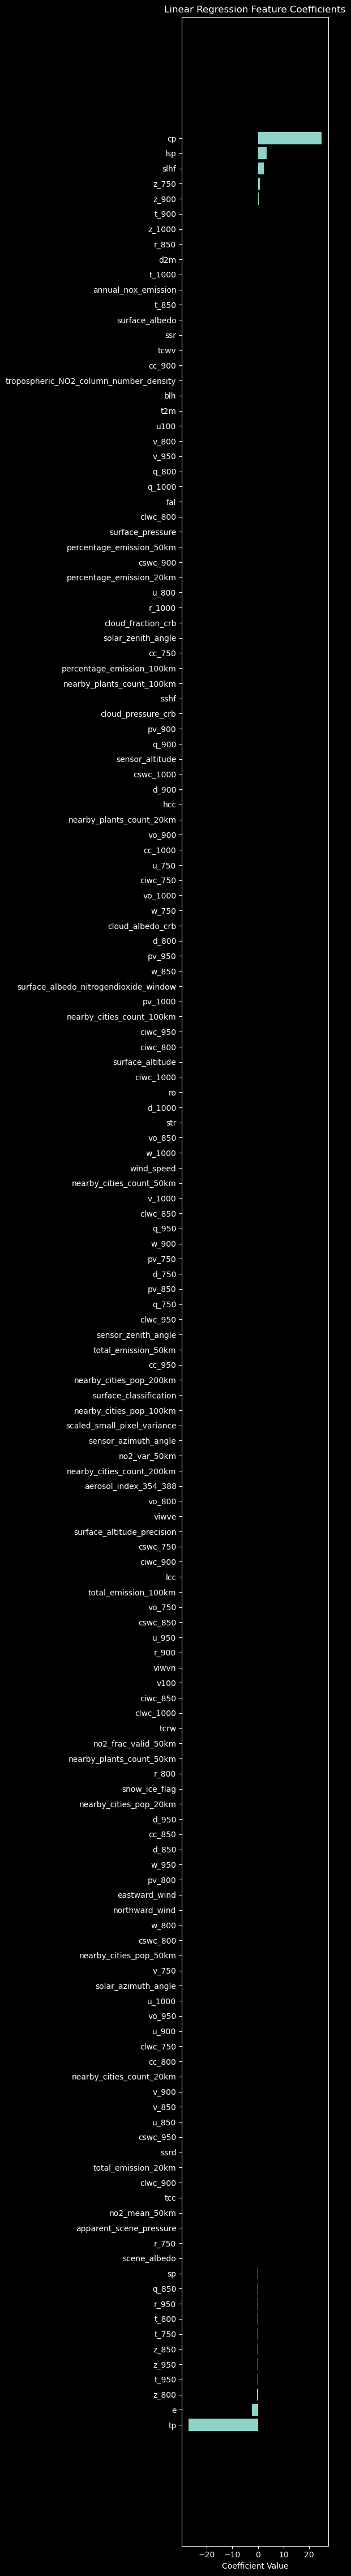

In [84]:
import numpy as np
import matplotlib.pyplot as plt

feature_names = X.columns
coefs = model.coef_  # for LinearRegression this is already 1-d

# sort for better visualization
indices = np.argsort(coefs)

plt.figure(figsize=(6, len(feature_names)*0.3))
plt.barh(feature_names[indices], coefs[indices])
plt.xlabel("Coefficient Value")
plt.title("Linear Regression Feature Coefficients")
plt.tight_layout()
plt.show()

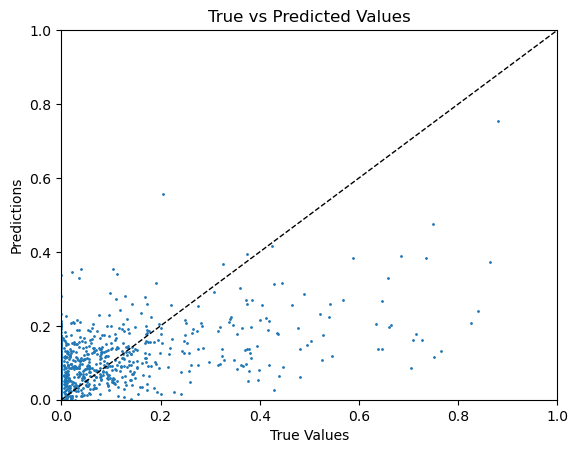

In [85]:
plt.rcdefaults()
plt.scatter(y_test, y_pred,s=1)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)  # identity line
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True vs Predicted Values")
plt.show()

In [7]:
df_means

,location,wind_u,wind_v,plume_label,annual_nox_emission,no2_mean_50km,no2_var_50km,no2_frac_valid_50km,surface_altitude,surface_altitude_precision,...,percentage_emission_100km,nearby_cities_count_20km,nearby_cities_pop_20km,nearby_cities_count_50km,nearby_cities_pop_50km,nearby_cities_count_100km,nearby_cities_pop_100km,nearby_cities_count_200km,nearby_cities_pop_200km,wind_speed
0,CoCO2_00006,3.523047,-2.018198,0.075314,5881.364106,0.000019,4.043600e-11,0.954014,139.042548,76.425969,...,99.952861,2.0,568884.0,4.0,1189611.0,6.0,1445134.0,23.0,4113568.0,4.228074
1,CoCO2_00007,5.398261,0.695366,0.000000,8168.561258,0.000029,1.975637e-10,0.952672,61.973039,21.486558,...,30.558001,5.0,12376210.0,6.0,12598738.0,7.0,12676014.0,12.0,13232705.0,5.667480
2,CoCO2_00008,-1.477974,-0.304918,0.004202,980.227351,0.000023,1.431925e-10,0.950309,1663.411715,34.011208,...,100.000000,1.0,665564.0,1.0,665564.0,7.0,1486208.0,25.0,4414362.0,2.343570
3,CoCO2_00009,-2.096192,-0.459157,0.000000,5227.879205,0.000015,4.909257e-11,0.936223,1842.333097,105.528307,...,100.000000,1.0,776249.0,3.0,1056063.0,3.0,1056063.0,10.0,2052883.0,3.097518
4,CoCO2_00010,5.447026,0.677386,0.000000,6273.455046,0.000030,1.952631e-10,0.952440,35.062604,30.120133,...,23.468545,4.0,11876210.0,7.0,12676014.0,7.0,12676014.0,12.0,13232705.0,5.693483
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,CoCO2_16411,1.318072,1.316161,0.188095,470.000000,0.000076,2.317300e-09,0.850310,33.006605,37.211558,...,3.232677,3.0,311269.0,7.0,824196.0,17.0,2777838.0,48.0,8059738.0,5.098302
5996,CoCO2_16417,0.784641,0.170133,0.079787,434.000000,0.000074,1.228245e-09,0.879173,44.749885,10.536387,...,9.903087,0.0,0.0,7.0,710658.0,21.0,3379722.0,71.0,18581564.0,4.191149
5997,CoCO2_16420,1.642037,0.983188,0.000000,258.000000,0.000065,1.023985e-09,0.867056,13.675498,16.545707,...,5.979032,1.0,707412.0,7.0,1723155.0,18.0,2831285.0,62.0,11964380.0,4.827516
5998,CoCO2_16422,1.119171,1.249138,0.009901,534.202000,0.000034,3.743112e-10,0.862851,15.652485,17.494482,...,19.253890,4.0,1732297.0,4.0,1732297.0,4.0,1732297.0,7.0,2209779.0,4.804617


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# Create location groups for power plants (same as your code)
tropomi_combined_dropna['location_group'] = (
    tropomi_combined_dropna['latitude'].round(2).astype(str) + '_' + 
    tropomi_combined_dropna['longitude'].round(2).astype(str)
)

print(f"Total samples: {len(tropomi_combined_dropna)}")
print(f"Unique power plants (locations): {tropomi_combined_dropna['location_group'].nunique()}")
print(f"Plume detection rate: {tropomi_combined_dropna['plume_label'].mean():.3f}")

# Prepare features and target
X = tropomi_combined_dropna.iloc[:, 9:].drop(['location_group'], axis=1, errors='ignore')
y = tropomi_combined_dropna["plume_label"].astype(bool)
groups = tropomi_combined_dropna['location_group']

# Split BY power plant - ensures same power plant doesn't appear in both train/test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Check the split
train_plants = groups.iloc[train_idx].nunique()
test_plants = groups.iloc[test_idx].nunique()
overlap_plants = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])

print(f"\nTrain set: {len(X_train)} samples from {train_plants} power plants")
print(f"Test set: {len(X_test)} samples from {test_plants} power plants")
print(f"Overlapping power plants: {len(overlap_plants)} (should be 0)")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate: {y_test.mean():.3f}")

# Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Power Plant Split Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Kappa: {cohen_kappa_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(model.coef_[0])
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))

Total samples: 875580
Unique power plants (locations): 4966
Plume detection rate: 0.089

Train set: 699657 samples from 3972 power plants
Test set: 175923 samples from 994 power plants
Overlapping power plants: 0 (should be 0)
Train positive rate: 0.089
Test positive rate: 0.091

=== Power Plant Split Results ===
Accuracy: 0.7788
Precision: 0.2817
Recall: 0.9267
F1 Score: 0.4321
AUC: 0.9132
Kappa: 0.3402

Confusion Matrix:
[[122201  37746]
 [  1171  14805]]

Classification Report:
              precision    recall  f1-score   support

       False       0.99      0.76      0.86    159947
        True       0.28      0.93      0.43     15976

    accuracy                           0.78    175923
   macro avg       0.64      0.85      0.65    175923
weighted avg       0.93      0.78      0.82    175923


Top 10 Features:
                                   feature  importance
39                  nearby_cities_pop_20km   33.912543
41                  nearby_cities_pop_50km   14.007458
38  

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# Create location groups for power plants (same as your code)
filtered_100['location_group'] = (
    filtered_100['latitude'].round(2).astype(str) + '_' + 
    filtered_100['longitude'].round(2).astype(str)
)

print(f"Total samples: {len(filtered_100)}")
print(f"Unique power plants (locations): {filtered_100['location_group'].nunique()}")
print(f"Plume detection rate: {filtered_100['plume_label'].mean():.3f}")

# Prepare features and target
X = filtered_100.iloc[:, 9:].drop(['location_group'], axis=1, errors='ignore')
y = filtered_100["plume_label"].astype(bool)
groups = filtered_100['location_group']

# Split BY power plant - ensures same power plant doesn't appear in both train/test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Check the split
train_plants = groups.iloc[train_idx].nunique()
test_plants = groups.iloc[test_idx].nunique()
overlap_plants = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])

print(f"\nTrain set: {len(X_train)} samples from {train_plants} power plants")
print(f"Test set: {len(X_test)} samples from {test_plants} power plants")
print(f"Overlapping power plants: {len(overlap_plants)} (should be 0)")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate: {y_test.mean():.3f}")

# Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Power Plant Split Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Kappa: {cohen_kappa_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(model.coef_[0])
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))

/tmp/ipykernel_20730/3079766003.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_100['location_group'] = (


Total samples: 15277
Unique power plants (locations): 100
Plume detection rate: 0.393

Train set: 12299 samples from 80 power plants
Test set: 2978 samples from 20 power plants
Overlapping power plants: 0 (should be 0)
Train positive rate: 0.374
Test positive rate: 0.473

=== Power Plant Split Results ===
Accuracy: 0.7411
Precision: 0.6810
Recall: 0.8525
F1 Score: 0.7572
AUC: 0.8129
Kappa: 0.4872

Confusion Matrix:
[[1005  563]
 [ 208 1202]]

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.64      0.72      1568
        True       0.68      0.85      0.76      1410

    accuracy                           0.74      2978
   macro avg       0.75      0.75      0.74      2978
weighted avg       0.76      0.74      0.74      2978


Top 10 Features:
                                   feature  importance
41                  nearby_cities_pop_50km    7.321239
7                         surface_pressure    1.531859
4                   

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# Create location groups for power plants (same as your code)
filtered_50['location_group'] = (
    filtered_50['latitude'].round(2).astype(str) + '_' + 
    filtered_50['longitude'].round(2).astype(str)
)

print(f"Total samples: {len(filtered_50)}")
print(f"Unique power plants (locations): {filtered_50['location_group'].nunique()}")
print(f"Plume detection rate: {filtered_50['plume_label'].mean():.3f}")

# Prepare features and target
X = filtered_50.iloc[:, 9:].drop(['location_group'], axis=1, errors='ignore')
y = filtered_50["plume_label"].astype(bool)
groups = filtered_50['location_group']

# Split BY power plant - ensures same power plant doesn't appear in both train/test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Check the split
train_plants = groups.iloc[train_idx].nunique()
test_plants = groups.iloc[test_idx].nunique()
overlap_plants = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])

print(f"\nTrain set: {len(X_train)} samples from {train_plants} power plants")
print(f"Test set: {len(X_test)} samples from {test_plants} power plants")
print(f"Overlapping power plants: {len(overlap_plants)} (should be 0)")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate: {y_test.mean():.3f}")

# Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Power Plant Split Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Kappa: {cohen_kappa_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(model.coef_[0])
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))

Total samples: 8081
Unique power plants (locations): 50
Plume detection rate: 0.425

Train set: 6600 samples from 40 power plants
Test set: 1481 samples from 10 power plants
Overlapping power plants: 0 (should be 0)
Train positive rate: 0.480
Test positive rate: 0.182

=== Power Plant Split Results ===
Accuracy: 0.7097
Precision: 0.2395
Recall: 0.2751
F1 Score: 0.2561
AUC: 0.6822
Kappa: 0.0768

Confusion Matrix:
[[977 235]
 [195  74]]

Classification Report:
              precision    recall  f1-score   support

       False       0.83      0.81      0.82      1212
        True       0.24      0.28      0.26       269

    accuracy                           0.71      1481
   macro avg       0.54      0.54      0.54      1481
weighted avg       0.73      0.71      0.72      1481


Top 10 Features:
                                   feature  importance
41                  nearby_cities_pop_50km    7.410433
7                         surface_pressure    1.249101
20  tropospheric_NO2_column

/tmp/ipykernel_20730/1829012001.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_50['location_group'] = (


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report, cohen_kappa_score
import matplotlib.pyplot as plt

# Create location groups for power plants (same as your code)
filtered_20['location_group'] = (
    filtered_20['latitude'].round(2).astype(str) + '_' + 
    filtered_20['longitude'].round(2).astype(str)
)

print(f"Total samples: {len(filtered_20)}")
print(f"Unique power plants (locations): {filtered_20['location_group'].nunique()}")
print(f"Plume detection rate: {filtered_20['plume_label'].mean():.3f}")

# Prepare features and target
X = filtered_20.iloc[:, 9:].drop(['location_group'], axis=1, errors='ignore')
y = filtered_20["plume_label"].astype(bool)
groups = filtered_20['location_group']

# Split BY power plant - ensures same power plant doesn't appear in both train/test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

# Check the split
train_plants = groups.iloc[train_idx].nunique()
test_plants = groups.iloc[test_idx].nunique()
overlap_plants = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])

print(f"\nTrain set: {len(X_train)} samples from {train_plants} power plants")
print(f"Test set: {len(X_test)} samples from {test_plants} power plants")
print(f"Overlapping power plants: {len(overlap_plants)} (should be 0)")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test positive rate: {y_test.mean():.3f}")

# Balance training data
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train_bal)

# Evaluate model
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Power Plant Split Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Kappa: {cohen_kappa_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(model.coef_[0])
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))

Total samples: 3315
Unique power plants (locations): 20
Plume detection rate: 0.370

Train set: 2553 samples from 16 power plants
Test set: 762 samples from 4 power plants
Overlapping power plants: 0 (should be 0)
Train positive rate: 0.342
Test positive rate: 0.463

=== Power Plant Split Results ===
Accuracy: 0.8045
Precision: 0.9048
Recall: 0.6459
F1 Score: 0.7537
AUC: 0.8755
Kappa: 0.5989

Confusion Matrix:
[[385  24]
 [125 228]]

Classification Report:
              precision    recall  f1-score   support

       False       0.75      0.94      0.84       409
        True       0.90      0.65      0.75       353

    accuracy                           0.80       762
   macro avg       0.83      0.79      0.80       762
weighted avg       0.82      0.80      0.80       762


Top 10 Features:
                                   feature  importance
42               nearby_cities_count_100km    2.441578
44               nearby_cities_count_200km    2.100418
33                     total_

/tmp/ipykernel_20730/3737630746.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_20['location_group'] = (
